[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/02_linear_maps_and_matrix_transformations/first_principles.ipynb)

# Module 02 — Linear Maps and Matrix Transformations

## 1. Why This Module Exists

A vector space is a set with two operations. A **linear map** is a function between two such
sets that respects both of them, and it is the only kind of function linear algebra studies.

The reason to single them out is economy. A linear map on an $n$-dimensional space is pinned
down by what it does to $n$ basis vectors, so an object defined on infinitely many inputs is
stored as $mn$ numbers.

Those $mn$ numbers are a matrix. This module builds the dictionary between maps and matrices,
proves that it is a perfect dictionary, and then reads the two structural theorems off it:
composition becomes matrix multiplication, and dimension is conserved as
$\dim V = \dim \ker T + \dim \operatorname{im} T$.

Everything downstream depends on this translation. A neural network layer, a rotation in a
renderer, a change of physical frame and a low-rank adapter are all one linear map written in
one basis rather than another.

## 2. Intuition

Picture the unit square in $\mathbb{R}^2$ with its grid lines drawn.

A linear map moves the square, and the two rules — additivity and homogeneity — say exactly
that the grid survives: straight lines stay straight, parallel lines stay parallel, evenly
spaced lines stay evenly spaced, and the origin does not move.

So the whole map is visible in the images of the two edge vectors $e_1$ and $e_2$. Everything
else is filled in by the grid, because every point of the plane is a combination
$x e_1 + y e_2$ and linearity forces $T(x e_1 + y e_2) = x\,T(e_1) + y\,T(e_2)$.

Write those two image vectors side by side as columns and you have the matrix. That is the
entire content of the representation theorem, and the $n$-dimensional case only replaces
"two edge vectors" by "$n$ basis vectors".

Two things can go wrong, and both are visible in the picture. The image square can be
flattened onto a line, which is loss of rank; and the same map can be drawn on a different
grid, which changes the numbers in the matrix without changing the map.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere below, and prints the machine epsilon that every later
residual claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the picture described above. It takes the unit square with its grid, sends
it through a shear, a rotation and a projection, and marks the images of $e_1$ and $e_2$ in
each panel.

It also prints the area of each image, computed from the polygon vertices by the shoelace
formula, so that the flattening in the third panel is a number and not an impression.

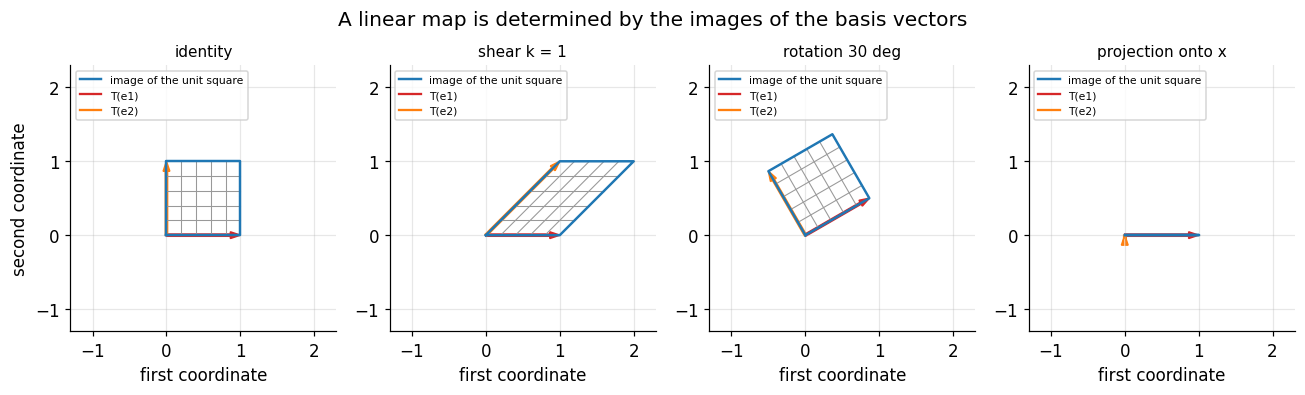

identity             T(e1) = [1. 0.]   T(e2) = [0. 1.]   area of image = 1.0000
shear k = 1          T(e1) = [1. 0.]   T(e2) = [1. 1.]   area of image = 1.0000
rotation 30 deg      T(e1) = [0.866 0.5  ]   T(e2) = [-0.5    0.866]   area of image = 1.0000
projection onto x    T(e1) = [1. 0.]   T(e2) = [0. 0.]   area of image = 0.0000


In [2]:
def unit_square_grid(k=5):
    """Outline of the unit square plus k interior grid lines in each direction."""
    segments = []
    for t in np.linspace(0.0, 1.0, k + 1):
        segments.append(np.array([[0.0, 1.0], [t, t]]))
        segments.append(np.array([[t, t], [0.0, 1.0]]))
    return segments


def shoelace(poly):
    """Unsigned area of a closed polygon given as a 2 x N array of vertices."""
    x, y = poly[0], poly[1]
    return 0.5 * abs(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y))


theta = np.deg2rad(30.0)
maps = {
    "identity": np.eye(2),
    "shear k = 1": np.array([[1.0, 1.0], [0.0, 1.0]]),
    "rotation 30 deg": np.array([[np.cos(theta), -np.sin(theta)],
                                 [np.sin(theta), np.cos(theta)]]),
    "projection onto x": np.array([[1.0, 0.0], [0.0, 0.0]]),
}
corners = np.array([[0.0, 1.0, 1.0, 0.0], [0.0, 0.0, 1.0, 1.0]])

fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.4))
for ax, (name, M) in zip(axes, maps.items()):
    for seg in unit_square_grid():
        img = M @ seg
        ax.plot(img[0], img[1], lw=0.7, color="0.6")
    closed = np.column_stack([M @ corners, (M @ corners)[:, :1]])
    ax.plot(closed[0], closed[1], lw=1.6, color="C0", label="image of the unit square")
    ax.arrow(0, 0, M[0, 0], M[1, 0], width=0.03, length_includes_head=True, color="C3")
    ax.arrow(0, 0, M[0, 1], M[1, 1], width=0.03, length_includes_head=True, color="C1")
    ax.plot([], [], color="C3", label="T(e1)")
    ax.plot([], [], color="C1", label="T(e2)")
    ax.set_aspect("equal")
    ax.set_xlim(-1.3, 2.3)
    ax.set_ylim(-1.3, 2.3)
    ax.set_xlabel("first coordinate")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("second coordinate")
fig.suptitle("A linear map is determined by the images of the basis vectors")
fig.tight_layout()
plt.show()

for name, M in maps.items():
    print(f"{name:20s} T(e1) = {M[:, 0]}   T(e2) = {M[:, 1]}   "
          f"area of image = {shoelace(M @ corners):.4f}")

The grid survives in every panel: lines stay straight, parallels stay parallel, and the origin
never moves. That is all linearity says.

The shear and the rotation keep the area at $1$. The projection returns area $0$: the square is
crushed onto a line, and one direction of the plane has been destroyed. That collapsed
direction is the kernel, and the surviving line is the image.

## 3. Definitions

Throughout, $V$ and $W$ are vector spaces over the same field $\mathbb{F}$, taken to be
$\mathbb{R}$ or $\mathbb{C}$. Vectors are columns, the transpose is written $A^{\top}$, and
norms are written $\lVert x \rVert$, following
[the notation register](../../docs/notation.md).

Unless a definition says otherwise, $\dim V = n$ with ordered basis
$B = (v_1, \dots, v_n)$ and $\dim W = m$ with ordered basis $C = (w_1, \dots, w_m)$. Vector
spaces, bases, dimension, quotients and dual spaces are taken from
[Module 01](../01_vectors_spaces_and_subspaces/first_principles.ipynb).

### Definition 3.1 — Linear map

A function $T : V \to W$ is a **linear map** when for all $u, v \in V$ and all
$c \in \mathbb{F}$,

$$
T(u + v) = T(u) + T(v), \qquad T(cu) = c\,T(u) .
$$

The two conditions are independent. Additivity alone does not give homogeneity: complex
conjugation on $\mathbb{C}$, viewed as a one-dimensional complex vector space, is additive and
fails $T(cz) = cT(z)$ at $c = i$. That failure is run in Section 7.3.

Both conditions together are equivalent to the single superposition rule
$T(cu + dv) = c\,T(u) + d\,T(v)$, and they force $T(0_V) = 0_W$ by taking $c = 0$.

### Definition 3.2 — The space of linear maps

$\mathcal{L}(V, W)$ denotes the set of all linear maps $V \to W$, with operations defined
pointwise:

$$
(S + T)(v) = S(v) + T(v), \qquad (cT)(v) = c\,\bigl(T(v)\bigr) .
$$

An **operator** is an element of $\mathcal{L}(V) = \mathcal{L}(V, V)$.

> **Notation callout.** Repository-wide, $\mathcal{L}$ is the Lagrangian. The symbol
> $\mathcal{L}(V, W)$ for the space of linear maps is a declared exception, confined to this
> module, and follows Axler. The two arguments in parentheses make it unambiguous.

### Definition 3.3 — Coordinate vector

For $x \in V$ the coefficients in $x = \sum_{j=1}^{n} c_j v_j$ are unique, because $B$ is a
basis. The **coordinate vector** of $x$ relative to $B$ is

$$
[x]_B = (c_1, \dots, c_n)^{\top} \in \mathbb{F}^{n} .
$$

The order of the basis matters: permuting $B$ permutes the entries of $[x]_B$, which is why
$B$ is a *tuple* and not a set.

### Definition 3.4 — Matrix of a linear map

The **matrix of $T$ relative to $B$ and $C$** is the $m \times n$ array
$[T]_{C,B}$ whose $j$-th column is $[T(v_j)]_C$. Written out, $a_{ij}$ is defined by

$$
T(v_j) = \sum_{i=1}^{m} a_{ij} w_i , \qquad j = 1, \dots, n .
$$

For an operator with the same basis on both sides we abbreviate $[T]_B = [T]_{B,B}$. When
$V = \mathbb{F}^n$, $W = \mathbb{F}^m$ and both bases are standard, $[T]_{C,B}$ is called the
**standard matrix** of $T$.

### Definition 3.5 — Kernel, image, nullity, rank

$$
\ker T = \lbrace v \in V \mid T(v) = 0_W \rbrace, \qquad
\operatorname{im} T = \lbrace T(v) \mid v \in V \rbrace .
$$

The **nullity** is $\operatorname{nullity}(T) = \dim \ker T$ and the **rank** is
$\operatorname{rank}(T) = \dim \operatorname{im} T$.

For a matrix $A \in \mathbb{F}^{m \times n}$ the same subspaces are written
$\operatorname{Null}(A)$ and $\operatorname{Col}(A)$, and $\operatorname{Row}(A) = \operatorname{Col}(A^{\top})$.
By definition $\operatorname{rank}(A) = \dim \operatorname{Col}(A)$, the **column rank**;
$\dim \operatorname{Row}(A)$ is the **row rank**. Theorem 4.7 proves they are equal.

### Definition 3.6 — Injective, surjective, isomorphism

$T$ is **injective** when $T(u) = T(v)$ forces $u = v$, **surjective** when
$\operatorname{im} T = W$, and an **isomorphism** when it is both. $V \cong W$ means an
isomorphism $V \to W$ exists.

$T$ is **invertible** when some $S \in \mathcal{L}(W, V)$ satisfies $S \circ T = \operatorname{id}_V$
and $T \circ S = \operatorname{id}_W$.

### Definition 3.7 — Change of basis, similarity, equivalence

For two ordered bases $B$ and $B'$ of the same space $V$, the **change-of-basis matrix** is

$$
P = [\operatorname{id}_V]_{B, B'},
$$

whose $j$-th column is $[v'_j]_B$. It converts $B'$-coordinates into $B$-coordinates.

Two matrices $A, A' \in \mathbb{F}^{n \times n}$ are **similar** when $A' = P^{-1} A P$ for some
invertible $P$. Two matrices $A, A' \in \mathbb{F}^{m \times n}$ are **equivalent** when
$A' = P A Q$ for invertible $P \in \mathbb{F}^{m \times m}$ and $Q \in \mathbb{F}^{n \times n}$.

Similarity is the relation between two matrices of one **operator** in two bases; equivalence
is the relation between two matrices of one **map** when the two bases may be changed
independently.

### Definition 3.8 — Dual space and dual map

The **dual space** $V' = \mathcal{L}(V, \mathbb{F})$ is the space of linear functionals on $V$.
The **dual basis** $B^{\star} = (f_1, \dots, f_n)$ of $B$ is defined by $f_i(v_j) = \delta_{ij}$.

The **dual map** of $T \in \mathcal{L}(V, W)$ is

$$
T' : W' \to V', \qquad T'(g) = g \circ T .
$$

It is linear, and Theorem 4.9 identifies its matrix as the transpose of the matrix of $T$.

### Definition 3.9 — Operator norm

For $A \in \mathbb{R}^{m \times n}$,

$$
\lVert A \rVert_{\mathrm{op}} = \max_{\lVert x \rVert_2 = 1} \lVert A x \rVert_2 .
$$

The maximum is attained because $x \mapsto \lVert Ax \rVert_2$ is continuous and the unit
sphere is compact. Directly from the definition, $\lVert Ax \rVert_2 \le \lVert A \rVert_{\mathrm{op}} \lVert x \rVert_2$
for every $x$, and hence $\lVert AB \rVert_{\mathrm{op}} \le \lVert A \rVert_{\mathrm{op}} \lVert B \rVert_{\mathrm{op}}$.

## 4. Main Results

Theorem 4.1 is the theorem this module is named after: linear maps and matrices are the same
objects once bases are fixed. Theorems 4.2 to 4.5 are its structural consequences — composition,
dimension counting, quotients, and the finite-dimensional dichotomy.

Theorems 4.6 to 4.9 ask what survives a change of basis, and answer with two normal forms:
similarity for operators, equivalence for maps. Proposition 4.10 places the four subspaces in
$\mathbb{R}^n$, and Proposition 4.11 is the one quantitative estimate the module needs later.

### Theorem 4.1 — Representation theorem

Let $V$ and $W$ be finite-dimensional over the same field $\mathbb{F}$, with
$\dim V = n$, $\dim W = m$, and fixed ordered bases $B$ of $V$ and $C$ of $W$.

**(i) Determination by a basis.** For any vectors $u_1, \dots, u_n \in W$ there is exactly one
$T \in \mathcal{L}(V, W)$ with $T(v_j) = u_j$ for all $j$.

**(ii) Coordinates.** For every $T \in \mathcal{L}(V, W)$ and every $x \in V$,

$$
[T(x)]_C = [T]_{C,B}\,[x]_B .
$$

**(iii) Dictionary.** The map $\Phi_{C,B} : \mathcal{L}(V, W) \to \mathbb{F}^{m \times n}$,
$T \mapsto [T]_{C,B}$, is an isomorphism of vector spaces. Consequently

$$
\dim \mathcal{L}(V, W) = mn .
$$

**Hypotheses.** Both spaces over the *same* field, or $c\,T(u)$ is not defined in $W$. $B$ a
basis: spanning gives existence of the coordinates in (ii), independence gives uniqueness in
(i). Finite dimension: an infinite basis has no finite column list.

**A warning about "canonical".** $\Phi_{C,B}$ depends on the two chosen bases. Change $B$ and
every column changes. The isomorphism $\mathcal{L}(V,W) \cong \mathbb{F}^{m \times n}$ is
basis-dependent, never canonical; the only canonical statement is that all these isomorphisms
are related by Theorem 4.6.

Proved as Proof 5.1.

### Theorem 4.2 — Composition is matrix multiplication

Let $U, V, W$ be finite-dimensional with ordered bases $A$, $B$, $C$. For
$T \in \mathcal{L}(U, V)$ and $S \in \mathcal{L}(V, W)$, the composite $S \circ T$ is linear and

$$
[S \circ T]_{C,A} = [S]_{C,B}\,[T]_{B,A} .
$$

**Hypotheses.** The basis $B$ of the middle space $V$ must be the *same* on both factors. Using
one basis to write $T$ and a different one to write $S$ produces a product that represents no
map at all; Section 7.3 measures the resulting error.

**Interpretation.** Matrix multiplication is not a definition chosen for convenience. It is
forced: it is the only rule that makes the dictionary of Theorem 4.1 respect composition.

Proved as Proof 5.2.

### Theorem 4.3 — Rank-nullity

Let $V$ be finite-dimensional and $T \in \mathcal{L}(V, W)$. Then $\ker T$ and
$\operatorname{im} T$ are subspaces of $V$ and $W$, and

$$
\dim V = \dim \ker T + \dim \operatorname{im} T .
$$

**Hypotheses.** Only $\dim V \lt \infty$; $W$ may be infinite-dimensional, since
$\operatorname{im} T$ is finite-dimensional anyway. If $\dim V = \infty$ the statement degenerates:
the multiplication operator of Section 7.3 has zero kernel and infinite-codimensional image.

**Interpretation.** Dimension is conserved. Whatever the domain loses to the kernel it fails to
deliver to the image, exactly.

Proved as Proof 5.3.

### Theorem 4.4 — First isomorphism theorem

Let $T \in \mathcal{L}(V, W)$, with $V$ any vector space. The map

$$
\bar{T} : V / \ker T \to \operatorname{im} T, \qquad \bar{T}(v + \ker T) = T(v)
$$

is a well-defined isomorphism.

**Hypotheses.** None beyond linearity; finite dimension is not needed. Quotienting by $\ker T$
rather than by an arbitrary subspace is what makes $\bar{T}$ well defined.

**Interpretation.** Every linear map factors as a quotient followed by an isomorphism followed
by an inclusion. In finite dimensions, taking dimensions recovers Theorem 4.3.

Proved as Proof 5.4.

### Theorem 4.5 — The finite-dimensional dichotomy

Let $\dim V = \dim W = n \lt \infty$ and $T \in \mathcal{L}(V, W)$. The following are
equivalent:

$$
T \text{ injective} \iff T \text{ surjective} \iff T \text{ bijective} \iff T \text{ invertible} .
$$

Moreover $V \cong W$ if and only if $\dim V = \dim W$.

**Hypotheses.** Equal *finite* dimensions. Both halves fail without finiteness: on the space
$\mathbb{R}[x]$ of all polynomials, $M(p) = x\,p$ is injective and not surjective, and
$D(p) = p'$ is surjective and not injective. Section 7.3 runs the first of these.

**Interpretation.** In finite dimensions a linear map cannot lose information in one place and
gain it in another. This is why a square system either has a unique solution for every
right-hand side or fails to be solvable for some.

Proved as Proof 5.5.

### Theorem 4.6 — Change of basis and similarity

Let $B$ and $B'$ be ordered bases of $V$ and let $P = [\operatorname{id}_V]_{B,B'}$.

**(i)** $P$ is invertible, $P^{-1} = [\operatorname{id}_V]_{B',B}$, and $[x]_B = P\,[x]_{B'}$ for all $x$.

**(ii)** For every operator $T \in \mathcal{L}(V)$,

$$
[T]_{B'} = P^{-1} [T]_B P .
$$

**(iii)** Similar matrices have the same rank and the same trace.

**Hypotheses.** In (ii) the *same* basis change is used on the domain and the codomain, because
$T$ maps $V$ to itself. Allowing two independent changes gives equivalence instead, which is
Theorem 4.7.

**Interpretation.** Similarity classes are operators; the entries of a matrix are an accident of
the chosen grid. Anything that deserves to be called a property of the operator must be a
similarity invariant.

Proved as Proof 5.6.

### Theorem 4.7 — Rank normal form, and row rank equals column rank

Let $A \in \mathbb{F}^{m \times n}$ have rank $r$. Then there exist invertible
$P \in \mathbb{F}^{m \times m}$ and $Q \in \mathbb{F}^{n \times n}$ with

$$
A = P \Sigma_r Q, \qquad
\Sigma_r = \begin{pmatrix} I_r & 0 \\ 0 & 0 \end{pmatrix} \in \mathbb{F}^{m \times n} .
$$

**Consequences.**

- Two $m \times n$ matrices are equivalent if and only if they have the same rank.
- $\operatorname{rank}(A^{\top}) = \operatorname{rank}(A)$: row rank equals column rank.
- **Rank factorization.** $A = CR$ with $C \in \mathbb{F}^{m \times r}$ and
  $R \in \mathbb{F}^{r \times n}$, both of rank $r$; the columns of $C$ are a basis of
  $\operatorname{Col}(A)$.

**Hypotheses.** None beyond finiteness of the dimensions. The price of allowing two independent
basis changes is that nothing but the rank survives.

Proved as Proof 5.7.

### Theorem 4.8 — Rank of a product

Let $A \in \mathbb{F}^{m \times n}$ and $B \in \mathbb{F}^{n \times p}$. Then

$$
\operatorname{rank}(A) + \operatorname{rank}(B) - n \;\le\; \operatorname{rank}(AB) \;\le\; \min \lbrace \operatorname{rank}(A), \operatorname{rank}(B) \rbrace .
$$

The lower bound is **Sylvester's rank inequality**.

**Hypotheses.** Only that the product is defined; $n$ in the lower bound is the shared inner
dimension, and the bound is vacuous when $n$ is large.

**Interpretation.** Composition can destroy rank but never create it. The lower bound says how
much rank a bottleneck of width $n$ is forced to keep, which is the statement a low-rank adapter
is built on.

Proved as Proof 5.8.

### Theorem 4.9 — The dual map is the transpose

Let $T \in \mathcal{L}(V, W)$ with bases $B$ of $V$, $C$ of $W$, and let $B^{\star}$, $C^{\star}$
be the corresponding dual bases. Then

$$
[T']_{B^{\star}, C^{\star}} = \bigl( [T]_{C,B} \bigr)^{\top},
\qquad \operatorname{rank}(T') = \operatorname{rank}(T) .
$$

**Hypotheses.** Finite dimension, so that the dual bases exist and $\dim V' = \dim V$.

**Interpretation.** The transpose is not an arbitrary reflection of an array. It is the matrix
of the map induced on linear functionals, and the equality of ranks is row rank equals column
rank read one level up.

Proved as Proof 5.9.

### Proposition 4.10 — The four subspaces of a real matrix

Let $A \in \mathbb{R}^{m \times n}$ have rank $r$, and equip $\mathbb{R}^n$ and $\mathbb{R}^m$
with the standard inner product. Then

$$
\operatorname{Null}(A) = \operatorname{Row}(A)^{\perp}, \qquad
\operatorname{Row}(A) = \operatorname{Null}(A)^{\perp},
$$

$$
\operatorname{Null}(A^{\top}) = \operatorname{Col}(A)^{\perp}, \qquad
\operatorname{Col}(A) = \operatorname{Null}(A^{\top})^{\perp},
$$

with dimensions $r$, $n - r$, $r$ and $m - r$ respectively.

**Hypotheses.** Real entries and the standard inner product; over $\mathbb{C}$ the transpose
must be replaced by the conjugate transpose. The second equality in each line needs
$(S^{\perp})^{\perp} = S$, which is *proved* in Proof 5.10 rather than assumed — it is false
for a non-closed subspace of an infinite-dimensional inner-product space.

Proved as Proof 5.10.

### Proposition 4.11 — Neumann series

Let $A \in \mathbb{R}^{n \times n}$ with $\lVert A \rVert_{\mathrm{op}} \lt 1$. Then $I - A$ is
invertible,

$$
(I - A)^{-1} = \sum_{k=0}^{\infty} A^{k},
$$

and the truncation $S_N = \sum_{k=0}^{N} A^{k}$ obeys

$$
\bigl\lVert (I - A)^{-1} - S_N \bigr\rVert_{\mathrm{op}} \;\le\; \frac{\lVert A \rVert_{\mathrm{op}}^{\,N+1}}{1 - \lVert A \rVert_{\mathrm{op}}} .
$$

**Hypotheses.** The strict inequality $\lVert A \rVert_{\mathrm{op}} \lt 1$ does two jobs: it
makes $I - A$ injective, hence invertible by Theorem 4.5, and it makes the geometric bound
summable. At $\lVert A \rVert_{\mathrm{op}} = 1$ both conclusions can fail, since $A = I$ leaves
$I - A = 0$.

**Interpretation.** A contraction can be inverted by iterating it, and the error falls by a
factor $\lVert A \rVert_{\mathrm{op}}$ per term. Section 7.2 measures that factor and exhibits a
matrix for which the bound is attained with equality.

Proved as Proof 5.11.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, the representation theorem)

**(i) Determination by a basis.**

*Existence.* Every $x \in V$ has unique coordinates $[x]_B = (c_1, \dots, c_n)^{\top}$, so

$$
T(x) := \sum_{j=1}^{n} c_j u_j
$$

is a well-defined function $V \to W$.

It is linear because coordinates are: if $[x]_B = (c_j)$ and $[y]_B = (d_j)$, then
$x + \alpha y = \sum_j (c_j + \alpha d_j) v_j$, and that expansion is the unique one, so
$[x + \alpha y]_B = [x]_B + \alpha [y]_B$. Applying the definition of $T$ to those coordinates
gives $T(x + \alpha y) = T(x) + \alpha T(y)$.

*Uniqueness.* If $T$ and $\widetilde{T}$ are linear and agree on every $v_j$, then for any $x$,

$$
T(x) = \sum_j c_j T(v_j) = \sum_j c_j \widetilde{T}(v_j) = \widetilde{T}(x) .
$$

**(ii) Coordinates.** Write $[T]_{C,B} = A = (a_{ij})$ and $[x]_B = (c_j)$. Then

$$
T(x) = T\Bigl( \sum_{j} c_j v_j \Bigr) = \sum_{j} c_j\, T(v_j) = \sum_{j} c_j \sum_{i} a_{ij} w_i .
$$

Exchanging the two finite sums groups the coefficient of $w_i$:

$$
T(x) = \sum_{i=1}^{m} \Bigl( \sum_{j=1}^{n} a_{ij} c_j \Bigr) w_i .
$$

The bracket is the $i$-th entry of $A[x]_B$, and coordinates relative to $C$ are unique, so
$[T(x)]_C = A [x]_B$.

**(iii) The dictionary is an isomorphism.**

*Linear.* The $j$-th column of $[S + \alpha T]_{C,B}$ is
$[(S + \alpha T)(v_j)]_C = [S(v_j)]_C + \alpha [T(v_j)]_C$, which is the $j$-th column of
$[S]_{C,B} + \alpha [T]_{C,B}$.

*Injective.* If $[T]_{C,B} = 0$ then $T(v_j) = 0$ for every $j$, and by the uniqueness in (i),
$T$ is the zero map.

*Surjective.* Given $A \in \mathbb{F}^{m \times n}$, set $u_j = \sum_i a_{ij} w_i$ and let $T$ be
the unique map from (i). Its $j$-th column is $[u_j]_C$, the $j$-th column of $A$.

*Dimension.* The matrices $E_{ij}$ with a single $1$ in position $(i,j)$ are a basis of
$\mathbb{F}^{m \times n}$, so that space has dimension $mn$; isomorphic spaces have equal
dimension. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, composition)

*Linearity of the composite.* For $u, u' \in U$ and $c \in \mathbb{F}$,

$$
(S \circ T)(cu + u') = S\bigl( c\,T(u) + T(u') \bigr) = c\,S(T(u)) + S(T(u')) .
$$

*The matrix.* Let $M = (m_{jk}) = [T]_{B,A}$ and $N = (n_{ij}) = [S]_{C,B}$, with
$A = (u_1, \dots, u_p)$, $B = (v_1, \dots, v_n)$, $C = (w_1, \dots, w_m)$.

Apply $S$ to the expansion of $T(u_k)$:

$$
(S \circ T)(u_k) = S\Bigl( \sum_{j=1}^{n} m_{jk} v_j \Bigr) = \sum_{j=1}^{n} m_{jk}\, S(v_j) .
$$

Expand $S(v_j)$ in the basis $C$ and exchange the sums:

$$
(S \circ T)(u_k) = \sum_{j=1}^{n} m_{jk} \sum_{i=1}^{m} n_{ij} w_i
= \sum_{i=1}^{m} \Bigl( \sum_{j=1}^{n} n_{ij} m_{jk} \Bigr) w_i .
$$

The bracket is the $(i,k)$ entry of the product $NM$, so
$[S \circ T]_{C,A} = [S]_{C,B} [T]_{B,A}$. $\blacksquare$

**Where the hypothesis enters.** The single basis $B$ was used twice: once to read the
coefficients $m_{jk}$ out of $T$, once to feed them into $S$. If the two lists of $v_j$ differ,
the exchange of sums above is between two unrelated expansions and the identity fails.

### Proof 5.3 (of Theorem 4.3, rank-nullity)

*The two sets are subspaces.* $T(0) = 0$ puts $0$ in both. If $T(u) = T(v) = 0$ then
$T(u + cv) = T(u) + c\,T(v) = 0$, so $\ker T$ is closed under the operations. If
$y = T(u)$ and $y' = T(v)$ then $y + cy' = T(u + cv)$, so $\operatorname{im} T$ is too.

*The count.* Let $n = \dim V$ and $k = \dim \ker T$.

**Step 1 — build a basis of $V$ adapted to $T$.** Take a basis $u_1, \dots, u_k$ of $\ker T$ and
extend it to a basis

$$
u_1, \dots, u_k, \; z_1, \dots, z_r \qquad \text{of } V, \qquad k + r = n,
$$

using the basis extension theorem of
[Module 01](../01_vectors_spaces_and_subspaces/first_principles.ipynb). When $k = 0$ the first
list is empty and when $k = n$ the second is; both degenerate cases are covered by the argument
below.

**Step 2 — the images of the added vectors span the image.** Any $y \in \operatorname{im} T$ is
$y = T(x)$ with $x = \sum_i c_i u_i + \sum_j d_j z_j$, so

$$
y = \sum_{i=1}^{k} c_i\, T(u_i) + \sum_{j=1}^{r} d_j\, T(z_j) = \sum_{j=1}^{r} d_j\, T(z_j),
$$

because each $T(u_i) = 0$.

**Step 3 — they are independent.** Suppose $\sum_j d_j T(z_j) = 0$. By linearity
$T\bigl( \sum_j d_j z_j \bigr) = 0$, so $\sum_j d_j z_j \in \ker T$ and therefore

$$
\sum_{j=1}^{r} d_j z_j = \sum_{i=1}^{k} c_i u_i
$$

for some scalars $c_i$. Moving everything to one side gives a linear relation among the vectors
of the basis built in Step 1, so every coefficient vanishes; in particular all $d_j = 0$.

**Step 4.** Steps 2 and 3 make $T(z_1), \dots, T(z_r)$ a basis of $\operatorname{im} T$, so
$\dim \operatorname{im} T = r = n - k$. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, the first isomorphism theorem)

Write $K = \ker T$ and recall from
[Module 01](../01_vectors_spaces_and_subspaces/first_principles.ipynb) that $V/K$ is the vector
space of cosets $v + K$ with $(v + K) + (u + K) = (v + u) + K$ and $c(v + K) = cv + K$.

**Well defined.** If $v + K = \tilde{v} + K$ then $v - \tilde{v} \in K$, so

$$
T(v) - T(\tilde{v}) = T(v - \tilde{v}) = 0 .
$$

The value $\bar{T}(v + K) = T(v)$ therefore does not depend on the representative. This is the
only step that uses $K = \ker T$ rather than an arbitrary subspace.

**Linear.** $\bar{T}\bigl( (v + K) + c(u + K) \bigr) = T(v + cu) = T(v) + c\,T(u)$.

**Injective.** If $\bar{T}(v + K) = 0$ then $T(v) = 0$, so $v \in K$ and $v + K$ is the zero
coset.

**Surjective onto $\operatorname{im} T$.** Every element of $\operatorname{im} T$ is $T(v)$ for
some $v$, and $T(v) = \bar{T}(v + K)$. $\blacksquare$

**Corollary.** If $\dim V \lt \infty$, taking dimensions and using
$\dim(V/K) = \dim V - \dim K$ recovers Theorem 4.3.

### Proof 5.5 (of Theorem 4.5, the dichotomy)

**Injective $\iff \ker T = \lbrace 0 \rbrace$.** If $T$ is injective and $T(v) = 0 = T(0)$ then
$v = 0$. Conversely if the kernel is trivial and $T(u) = T(v)$ then $T(u - v) = 0$, so $u = v$.

**Injective $\iff$ surjective.** By Theorem 4.3,

$$
\dim \operatorname{im} T = n - \dim \ker T .
$$

So $T$ injective means $\dim \operatorname{im} T = n = \dim W$; a subspace of $W$ with the same
finite dimension as $W$ is $W$ itself, so $T$ is surjective. Conversely $T$ surjective gives
$\dim \operatorname{im} T = n$, hence $\dim \ker T = 0$.

**Bijective $\iff$ invertible.** An invertible map is bijective, since $T \circ S = \operatorname{id}_W$
forces surjectivity and $S \circ T = \operatorname{id}_V$ forces injectivity.

Conversely let $T$ be bijective and let $S$ be its set-theoretic inverse. For
$y, y' \in W$ write $y = T(x)$, $y' = T(x')$. Then

$$
S(y + cy') = S\bigl( T(x + cx') \bigr) = x + cx' = S(y) + c\,S(y'),
$$

so $S$ is linear and $T$ is invertible.

**Isomorphism criterion.** If $T : V \to W$ is an isomorphism then $\dim \ker T = 0$ and
$\operatorname{im} T = W$, so Theorem 4.3 gives $\dim V = \dim W$. Conversely, if
$\dim V = \dim W = n$, pick bases $(v_j)$ and $(w_j)$ and let $T$ be the unique map with
$T(v_j) = w_j$ from Theorem 4.1(i). It is surjective because its image contains a basis of $W$,
hence bijective by the equivalence just proved. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, change of basis)

**(i)** Apply Theorem 4.2 to $\operatorname{id}_V \circ \operatorname{id}_V = \operatorname{id}_V$
with the three bases $B'$, $B$, $B'$:

$$
[\operatorname{id}]_{B',B}\,[\operatorname{id}]_{B,B'} = [\operatorname{id}]_{B',B'} = I,
$$

and with $B$, $B'$, $B$ in the other order, $[\operatorname{id}]_{B,B'}[\operatorname{id}]_{B',B} = I$.
So $P = [\operatorname{id}]_{B,B'}$ is invertible with inverse $[\operatorname{id}]_{B',B}$.

Theorem 4.1(ii) applied to $\operatorname{id}$ gives $[x]_B = [\operatorname{id}(x)]_B = P [x]_{B'}$.

**(ii)** Write $T = \operatorname{id} \circ T \circ \operatorname{id}$ and read the bases
$B', B, B, B'$ across the composite. Theorem 4.2 twice gives

$$
[T]_{B'} = [\operatorname{id}]_{B',B}\,[T]_{B,B}\,[\operatorname{id}]_{B,B'} = P^{-1} [T]_B P .
$$

**(iii) Rank.** For invertible $Q$ the columns of $AQ$ are combinations of the columns of $A$ and
conversely, since $A = (AQ)Q^{-1}$, so $\operatorname{Col}(AQ) = \operatorname{Col}(A)$. For
invertible $P$, $\operatorname{Col}(PA) = P\,\operatorname{Col}(A)$, and an injective linear map
preserves the dimension of a subspace by Theorem 4.3. Hence
$\operatorname{rank}(P^{-1}AP) = \operatorname{rank}(A)$.

**(iii) Trace.** Directly from the definition, for $X \in \mathbb{F}^{n \times p}$ and
$Y \in \mathbb{F}^{p \times n}$,

$$
\operatorname{tr}(XY) = \sum_{i=1}^{n} \sum_{j=1}^{p} x_{ij} y_{ji} = \operatorname{tr}(YX) .
$$

Taking $X = P^{-1}$ and $Y = AP$ gives
$\operatorname{tr}(P^{-1}AP) = \operatorname{tr}(APP^{-1}) = \operatorname{tr}(A)$. $\blacksquare$

**Not used here.** The determinant and the characteristic polynomial are also similarity
invariants. Both are built in
[Module 05](../05_determinants_trace_and_matrix_polynomials/first_principles.ipynb), and no
argument in this module relies on them.

### Proof 5.7 (of Theorem 4.7, rank normal form)

Let $r = \operatorname{rank}(A)$ and read $A$ as the map $x \mapsto Ax$ from $\mathbb{F}^n$ to
$\mathbb{F}^m$.

**Step 1 — adapted basis of the domain.** As in Proof 5.3, take a basis $u_1, \dots, u_{n-r}$ of
$\operatorname{Null}(A)$ and extend by $z_1, \dots, z_r$ to a basis of $\mathbb{F}^n$. Proof 5.3
also gives that $Az_1, \dots, Az_r$ is a basis of $\operatorname{Col}(A)$.

**Step 2 — adapted basis of the codomain.** Extend $Az_1, \dots, Az_r$ by
$y_{r+1}, \dots, y_m$ to a basis of $\mathbb{F}^m$.

**Step 3 — assemble.** Put

$$
X = \begin{pmatrix} z_1 & \cdots & z_r & u_1 & \cdots & u_{n-r} \end{pmatrix} \in \mathbb{F}^{n \times n},
\qquad
P = \begin{pmatrix} Az_1 & \cdots & Az_r & y_{r+1} & \cdots & y_m \end{pmatrix} \in \mathbb{F}^{m \times m} .
$$

Both have a basis as columns, so both are invertible. Column by column,

$$
AX = \begin{pmatrix} Az_1 & \cdots & Az_r & 0 & \cdots & 0 \end{pmatrix} = P \Sigma_r ,
$$

since $P\Sigma_r$ keeps the first $r$ columns of $P$ and zeroes the rest. Setting $Q = X^{-1}$
gives $A = P \Sigma_r Q$.

**Consequence 1 — equivalence classes.** If $A$ and $A'$ have the same rank $r$, both equal
$P \Sigma_r Q$ for suitable invertible factors, so each is obtainable from the other. Conversely
Proof 5.6(iii) shows multiplying by invertible matrices leaves the rank unchanged.

**Consequence 2 — row rank equals column rank.** Transposing,

$$
A^{\top} = Q^{\top} \Sigma_r^{\top} P^{\top} ,
$$

with $Q^{\top}$ and $P^{\top}$ invertible, so $\operatorname{rank}(A^{\top}) = \operatorname{rank}(\Sigma_r^{\top}) = r$.
Since $\operatorname{rank}(A^{\top}) = \dim \operatorname{Col}(A^{\top}) = \dim \operatorname{Row}(A)$,
the row rank equals the column rank.

**Consequence 3 — rank factorization.** Split the product: let $C$ be the first $r$ columns of
$P$ and $R$ the first $r$ rows of $Q$. Then $\Sigma_r Q$ has those $r$ rows on top and zeros
below, so

$$
A = P \Sigma_r Q = C R .
$$

$C$ has rank $r$ because its columns are $r$ columns of an invertible matrix, and $R$ has rank
$r$ for the same reason applied to rows. Finally $\operatorname{Col}(A) \subseteq \operatorname{Col}(C)$
and both have dimension $r$, so they are equal. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, rank of a product)

**Upper bound, first half.** Every column of $AB$ has the form $A(Bx)$, so
$\operatorname{Col}(AB) \subseteq \operatorname{Col}(A)$ and
$\operatorname{rank}(AB) \le \operatorname{rank}(A)$.

**Upper bound, second half, and Sylvester.** Note $\operatorname{Col}(AB) = A\bigl( \operatorname{Col}(B) \bigr)$,
so apply Theorem 4.3 to the restriction of $x \mapsto Ax$ to the subspace $\operatorname{Col}(B)$:

$$
\operatorname{rank}(B) = \dim \operatorname{Col}(B)
= \dim A\bigl( \operatorname{Col}(B) \bigr) + \dim \bigl( \operatorname{Col}(B) \cap \operatorname{Null}(A) \bigr) .
$$

The first term on the right is $\operatorname{rank}(AB)$, which gives
$\operatorname{rank}(AB) \le \operatorname{rank}(B)$ immediately.

For the lower bound, bound the intersection by the whole null space and use Theorem 4.3 on $A$:

$$
\dim \bigl( \operatorname{Col}(B) \cap \operatorname{Null}(A) \bigr) \le \dim \operatorname{Null}(A) = n - \operatorname{rank}(A) .
$$

Substituting and rearranging,

$$
\operatorname{rank}(AB) \ge \operatorname{rank}(B) - \bigl( n - \operatorname{rank}(A) \bigr) = \operatorname{rank}(A) + \operatorname{rank}(B) - n . \qquad \blacksquare
$$

### Proof 5.9 (of Theorem 4.9, the dual map)

*Linearity of $T'$.* For $g, h \in W'$ and $c \in \mathbb{F}$,
$T'(g + ch) = (g + ch) \circ T = g \circ T + c\,(h \circ T)$.

*The matrix.* Let $B^{\star} = (f_1, \dots, f_n)$ and $C^{\star} = (g_1, \dots, g_m)$ be the
dual bases, and $A = (a_{ij}) = [T]_{C,B}$.

The $i$-th column of $[T']_{B^{\star}, C^{\star}}$ holds the coordinates of $T'(g_i)$ in the
basis $B^{\star}$. A functional $\varphi \in V'$ has coordinates $\varphi(v_j)$ in that basis,
because $\varphi = \sum_j \varphi(v_j) f_j$ agrees with $\varphi$ on every $v_j$.

Therefore the $(j, i)$ entry is

$$
\bigl( T'(g_i) \bigr)(v_j) = g_i\bigl( T(v_j) \bigr) = g_i\Bigl( \sum_{k=1}^{m} a_{kj} w_k \Bigr) = a_{ij},
$$

using $g_i(w_k) = \delta_{ik}$. An array whose $(j,i)$ entry is $a_{ij}$ is $A^{\top}$.

*Ranks.* $\operatorname{rank}(T') = \operatorname{rank}(A^{\top}) = \operatorname{rank}(A) = \operatorname{rank}(T)$
by Consequence 2 of Proof 5.7. $\blacksquare$

### Proof 5.10 (of Proposition 4.10, the four subspaces)

**Step 1 — the null space is the orthogonal complement of the rows.** Let $r_1, \dots, r_m$ be
the rows of $A$. Then $Ax = 0$ says $r_i^{\top} x = 0$ for every $i$.

A vector orthogonal to each $r_i$ is orthogonal to every linear combination of them, by
bilinearity of the inner product, and conversely. Hence

$$
\operatorname{Null}(A) = \operatorname{Row}(A)^{\perp} .
$$

**Step 2 — the lemma.** For any subspace $S \subseteq \mathbb{R}^n$,

$$
\dim S + \dim S^{\perp} = n \qquad \text{and} \qquad (S^{\perp})^{\perp} = S .
$$

Let $s_1, \dots, s_k$ be a basis of $S$ and let $M \in \mathbb{R}^{k \times n}$ have those
vectors as its rows. Then $S = \operatorname{Row}(M)$, and Step 1 gives
$S^{\perp} = \operatorname{Null}(M)$.

Theorem 4.3 applied to $x \mapsto Mx$ gives $n = \operatorname{rank}(M) + \dim \operatorname{Null}(M)$.
The rows of $M$ are independent, so its row rank is $k$, and by Consequence 2 of Proof 5.7 its
column rank is $k$ as well. Hence $\dim S^{\perp} = n - k$.

Now $S \subseteq (S^{\perp})^{\perp}$ holds by definition, and applying the dimension count twice
gives $\dim (S^{\perp})^{\perp} = n - (n - k) = k = \dim S$. A subspace contained in another of
the same finite dimension is equal to it.

**Step 3 — assemble.** Applying Step 2 to $S = \operatorname{Row}(A)$ and using Step 1,

$$
\operatorname{Null}(A)^{\perp} = \bigl( \operatorname{Row}(A)^{\perp} \bigr)^{\perp} = \operatorname{Row}(A) .
$$

Replacing $A$ by $A^{\top}$ turns rows into columns and gives the second pair. The dimensions are
$\operatorname{rank}(A) = r$ for $\operatorname{Col}(A)$ and $\operatorname{Row}(A)$ by Proof 5.7,
then $n - r$ and $m - r$ for the two null spaces by Theorem 4.3. $\blacksquare$

**Where finiteness is used.** Step 2 counts dimensions, and the last sentence needs the
containment to be an equality of finite-dimensional spaces. In an infinite-dimensional inner
product space $(S^{\perp})^{\perp}$ is the *closure* of $S$, and equals $S$ only when $S$ is
closed.

### Proof 5.11 (of Proposition 4.11, the Neumann series)

**Step 1 — $I - A$ is invertible.** If $(I - A)x = 0$ then $x = Ax$, so

$$
\lVert x \rVert_2 = \lVert Ax \rVert_2 \le \lVert A \rVert_{\mathrm{op}} \lVert x \rVert_2,
\qquad \text{hence} \qquad \bigl( 1 - \lVert A \rVert_{\mathrm{op}} \bigr) \lVert x \rVert_2 \le 0 .
$$

The bracket is positive, so $x = 0$: the map is injective, and Theorem 4.5 makes it invertible.

**Step 2 — bound the inverse.** Given $y$, put $x = (I - A)^{-1} y$, so $y = x - Ax$. The reverse
triangle inequality gives

$$
\lVert y \rVert_2 \ge \lVert x \rVert_2 - \lVert Ax \rVert_2 \ge \bigl( 1 - \lVert A \rVert_{\mathrm{op}} \bigr) \lVert x \rVert_2 ,
$$

so $\lVert (I - A)^{-1} \rVert_{\mathrm{op}} \le \bigl( 1 - \lVert A \rVert_{\mathrm{op}} \bigr)^{-1}$.

**Step 3 — telescope.** Expanding the product term by term,

$$
(I - A) S_N = \sum_{k=0}^{N} A^{k} - \sum_{k=1}^{N+1} A^{k} = I - A^{N+1} .
$$

Multiplying on the left by $(I - A)^{-1}$ and rearranging,

$$
(I - A)^{-1} - S_N = (I - A)^{-1} A^{N+1} .
$$

**Step 4 — measure.** Submultiplicativity from Definition 3.9 gives

$$
\bigl\lVert (I - A)^{-1} - S_N \bigr\rVert_{\mathrm{op}} \le \lVert (I - A)^{-1} \rVert_{\mathrm{op}} \, \lVert A \rVert_{\mathrm{op}}^{\,N+1} \le \frac{\lVert A \rVert_{\mathrm{op}}^{\,N+1}}{1 - \lVert A \rVert_{\mathrm{op}}} .
$$

The right-hand side tends to $0$, so $S_N \to (I - A)^{-1}$. $\blacksquare$

## 6. Worked Examples

Every example below is small enough to finish by hand, and each main result of Section 4 gets
one. Two code cells recompute the numbers and assert agreement.

### Example 6.1 — The matrix of an operator in a non-standard basis (Theorems 4.1 and 4.6)

Let $T : \mathbb{R}^2 \to \mathbb{R}^2$ be $T(x, y) = (2x + y,\; x - y)$ and let

$$
B = \bigl( (1, 1),\; (1, -1) \bigr) .
$$

*Standard matrix.* $T(e_1) = (2, 1)$ and $T(e_2) = (1, -1)$, so

$$
[T]_E = \begin{pmatrix} 2 & 1 \\ 1 & -1 \end{pmatrix}.
$$

*Images of the new basis.* $T(1, 1) = (3, 0)$ and $T(1, -1) = (1, 2)$.

*Coordinates in $B$.* Solving $(a, b) = c_1 (1,1) + c_2 (1,-1)$ gives
$c_1 = \tfrac{a+b}{2}$, $c_2 = \tfrac{a-b}{2}$. Hence

$$
[T(1,1)]_B = \Bigl( \tfrac{3}{2}, \tfrac{3}{2} \Bigr)^{\top},
\qquad
[T(1,-1)]_B = \Bigl( \tfrac{3}{2}, -\tfrac{1}{2} \Bigr)^{\top},
$$

so the matrix of the same operator on the new grid is

$$
[T]_B = \begin{pmatrix} \tfrac{3}{2} & \tfrac{3}{2} \\[2pt] \tfrac{3}{2} & -\tfrac{1}{2} \end{pmatrix}.
$$

*Cross-check by Theorem 4.6.* With $P = \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$ and
$P^{-1} = \tfrac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$,

$$
[T]_E P = \begin{pmatrix} 3 & 1 \\ 0 & 2 \end{pmatrix},
\qquad
P^{-1}\bigl( [T]_E P \bigr) = \tfrac{1}{2}\begin{pmatrix} 3 & 3 \\ 3 & -1 \end{pmatrix} = [T]_B .
$$

**Interpretation.** Four entries changed and nothing about the operator did. The trace stayed at
$1$ and the rank at $2$, exactly as Theorem 4.6(iii) requires.

### Example 6.2 — Both bases non-standard, and the spaces different (Theorem 4.1)

Let $T : P_2 \to \mathbb{R}^2$ be $T(p) = \bigl( p(1),\; p'(0) \bigr)$, with

$$
B = \bigl( 1,\; 1 + x,\; 1 + x + x^2 \bigr), \qquad C = \bigl( (1,1),\; (1,-1) \bigr) .
$$

*Images of the basis.*

$$
T(1) = (1, 0), \qquad T(1 + x) = (2, 1), \qquad T(1 + x + x^2) = (3, 1) .
$$

*Coordinates in $C$*, using the same $\bigl( \tfrac{a+b}{2}, \tfrac{a-b}{2} \bigr)$ rule:

$$
\Bigl( \tfrac{1}{2}, \tfrac{1}{2} \Bigr), \qquad
\Bigl( \tfrac{3}{2}, \tfrac{1}{2} \Bigr), \qquad
(2, 1) .
$$

Stacking them as columns,

$$
[T]_{C,B} = \begin{pmatrix} \tfrac{1}{2} & \tfrac{3}{2} & 2 \\[2pt] \tfrac{1}{2} & \tfrac{1}{2} & 1 \end{pmatrix}.
$$

*Test on one vector.* Take $p = 2 + 3x - x^2$. Matching coefficients in
$p = c_1 \cdot 1 + c_2 (1+x) + c_3 (1 + x + x^2)$ gives $c_3 = -1$, then $c_2 = 4$, then
$c_1 = -1$, so $[p]_B = (-1, 4, -1)^{\top}$.

Directly, $T(p) = \bigl( p(1), p'(0) \bigr) = (4, 3)$, whose $C$-coordinates are
$\bigl( \tfrac{7}{2}, \tfrac{1}{2} \bigr)$. Through the matrix,

$$
[T]_{C,B}\,[p]_B = \Bigl( -\tfrac{1}{2} + 6 - 2,\; -\tfrac{1}{2} + 2 - 1 \Bigr)^{\top} = \Bigl( \tfrac{7}{2}, \tfrac{1}{2} \Bigr)^{\top} .
$$

**Interpretation.** Neither space is $\mathbb{R}^n$ with its standard basis, and one of them is a
space of polynomials, yet the entire map is six numbers. That is the economy Theorem 4.1 buys.

### Example 6.3 — Composition, in two settings (Theorem 4.2)

*Order matters.* Let $R$ rotate by $90$ degrees counterclockwise and $F$ reflect across the
$y$-axis:

$$
R = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}, \qquad
F = \begin{pmatrix} -1 & 0 \\ 0 & 1 \end{pmatrix} .
$$

Then

$$
[F \circ R]_E = F R = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix},
\qquad
[R \circ F]_E = R F = \begin{pmatrix} 0 & -1 \\ -1 & 0 \end{pmatrix} .
$$

The first is the reflection across the line $y = x$, the second across $y = -x$. Composition is
not commutative, and neither is matrix multiplication.

*Across three spaces with non-standard bases.* Compose the map $T : P_2 \to \mathbb{R}^2$ of
Example 6.2 with the operator $S(x,y) = (2x + y,\; x - y)$ of Example 6.1, using the basis $C$
for the middle space on both factors:

$$
[S \circ T]_{C,B} = [S]_C \, [T]_{C,B}
= \begin{pmatrix} \tfrac{3}{2} & \tfrac{3}{2} \\[2pt] \tfrac{3}{2} & -\tfrac{1}{2} \end{pmatrix}
\begin{pmatrix} \tfrac{1}{2} & \tfrac{3}{2} & 2 \\[2pt] \tfrac{1}{2} & \tfrac{1}{2} & 1 \end{pmatrix}
= \begin{pmatrix} \tfrac{3}{2} & 3 & \tfrac{9}{2} \\[2pt] \tfrac{1}{2} & 2 & \tfrac{5}{2} \end{pmatrix}.
$$

Checking the first column directly: $(S \circ T)(1) = S(1, 0) = (2, 1)$, whose $C$-coordinates
are $\bigl( \tfrac{3}{2}, \tfrac{1}{2} \bigr)$.

**Interpretation.** The middle basis $C$ appears twice and cancels. That cancellation is the
whole mechanism of Theorem 4.2, and Section 7.3 shows what happens when it is broken.

### Example 6.4 — Rank, nullity and two factorizations of one matrix (Theorems 4.3, 4.7, 4.8)

Take

$$
A = \begin{pmatrix} 1 & 2 & 0 & -1 \\ 2 & 4 & 1 & 1 \\ 3 & 6 & 1 & 0 \end{pmatrix}
\in \mathbb{R}^{3 \times 4} .
$$

*Row reduction.* $R_2 \leftarrow R_2 - 2R_1$ and $R_3 \leftarrow R_3 - 3R_1$ both give
$(0, 0, 1, 3)$, and subtracting one from the other clears the last row:

$$
\operatorname{rref}(A) = \begin{pmatrix} 1 & 2 & 0 & -1 \\ 0 & 0 & 1 & 3 \\ 0 & 0 & 0 & 0 \end{pmatrix},
\qquad \text{pivots in columns } 1 \text{ and } 3 .
$$

So $\operatorname{rank}(A) = 2$ and, by Theorem 4.3, $\dim \operatorname{Null}(A) = 4 - 2 = 2$.

*Null space.* With $x_2$ and $x_4$ free, $x_1 = -2x_2 + x_4$ and $x_3 = -3x_4$:

$$
\operatorname{Null}(A) = \operatorname{span}\lbrace (-2, 1, 0, 0)^{\top},\; (1, 0, -3, 1)^{\top} \rbrace .
$$

*Rank factorization.* The pivot columns $(1,2,3)^{\top}$ and $(0,1,1)^{\top}$ are a basis of
$\operatorname{Col}(A)$, and the non-zero rows of the reduced form give the coefficients:

$$
A = CR = \begin{pmatrix} 1 & 0 \\ 2 & 1 \\ 3 & 1 \end{pmatrix}
\begin{pmatrix} 1 & 2 & 0 & -1 \\ 0 & 0 & 1 & 3 \end{pmatrix}.
$$

*Rank normal form.* Following Proof 5.7, take $z_1 = e_1$, $z_2 = e_3$ and the two null vectors
above:

$$
X = \begin{pmatrix} 1 & 0 & -2 & 1 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & -3 \\ 0 & 0 & 0 & 1 \end{pmatrix},
\qquad
P = \begin{pmatrix} 1 & 0 & 1 \\ 2 & 1 & 0 \\ 3 & 1 & 0 \end{pmatrix},
\qquad
A X = P \Sigma_2 ,
$$

so $A = P \Sigma_2 X^{-1}$ with $\Sigma_2$ the $3 \times 4$ array carrying $I_2$ in its corner.

*Row rank.* Row $3$ equals row $1$ plus row $2$, and rows $1, 2$ are independent, so the row rank
is $2$ — equal to the column rank, as Theorem 4.7 requires.

**Interpretation.** One matrix, three readings: two dimensions of input are destroyed, two
survive, and the surviving part is a $2 \times 2$ identity once both grids are chosen well.

### Example 6.5 — The quotient made explicit (Theorems 4.4 and 4.5)

Let $T : \mathbb{R}^3 \to \mathbb{R}^2$ be $T(x, y, z) = (x + y,\; y + z)$.

*Kernel.* $x + y = 0$ and $y + z = 0$ give $x = -y$, $z = -y$, so

$$
\ker T = \operatorname{span}\lbrace (1, -1, 1)^{\top} \rbrace, \qquad \dim \ker T = 1 .
$$

*Image.* $T(1,0,0) = (1,0)$ and $T(0,0,1) = (0,1)$, so $\operatorname{im} T = \mathbb{R}^2$ and
$\operatorname{rank}(T) = 2$. Theorem 4.3 checks out: $3 = 1 + 2$.

*The induced isomorphism.* Theorem 4.4 gives
$\mathbb{R}^3 / \ker T \cong \mathbb{R}^2$, with

$$
\bar{T}\bigl( (1,0,0) + \ker T \bigr) = (1,0), \qquad
\bar{T}\bigl( (0,0,1) + \ker T \bigr) = (0,1) .
$$

*Well-definedness, checked on one coset.* The vectors $(1,0,0)$ and
$(1,0,0) + 3(1,-1,1) = (4,-3,3)$ represent the same coset, and

$$
T(4, -3, 3) = (4 - 3,\; -3 + 3) = (1, 0) = T(1, 0, 0) .
$$

*A dichotomy check.* $T$ is surjective but not injective, which is allowed because
$\dim \mathbb{R}^3 \neq \dim \mathbb{R}^2$. Theorem 4.5 forbids this only when the two dimensions
agree.

### Example 6.6 — The dual map and the four subspaces (Theorem 4.9, Proposition 4.10)

Keep $A$ from Example 6.4 and let $T(x) = Ax$.

*A functional and its pullback.* Take $g \in (\mathbb{R}^3)'$ with $g(y) = y_1 - y_2$, whose
coordinates in the standard dual basis are $(1, -1, 0)$. Then

$$
T'(g)(x) = g(Ax) = (Ax)_1 - (Ax)_2 = (r_1 - r_2)^{\top} x, \qquad r_1 - r_2 = (-1, -2, -1, -2) .
$$

The same vector is produced by the transpose:

$$
A^{\top} (1, -1, 0)^{\top} = (-1, -2, -1, -2)^{\top} ,
$$

which is Theorem 4.9 on one column.

*Orthogonality.* The rows $r_1 = (1,2,0,-1)$ and $r_2 = (2,4,1,1)$ are a basis of
$\operatorname{Row}(A)$, and both are orthogonal to both null-space basis vectors:

$$
r_1^{\top}(-2,1,0,0) = 0, \quad r_1^{\top}(1,0,-3,1) = 0, \quad
r_2^{\top}(-2,1,0,0) = 0, \quad r_2^{\top}(1,0,-3,1) = 0 .
$$

Dimensions: $\dim \operatorname{Row}(A) + \dim \operatorname{Null}(A) = 2 + 2 = 4$, so the two
subspaces are full orthogonal complements in $\mathbb{R}^4$ and not merely orthogonal.

**Interpretation.** The count is what upgrades "orthogonal" to "orthogonal complement". Without
Proof 5.10's dimension lemma, $\operatorname{Row}(A) \subseteq \operatorname{Null}(A)^{\perp}$
would be all one could say.

### Example 6.7 — A contraction inverted by iteration (Proposition 4.11)

Let

$$
A = \begin{pmatrix} 0 & \tfrac{1}{2} \\[2pt] -\tfrac{1}{2} & 0 \end{pmatrix},
\qquad \lVert A \rVert_{\mathrm{op}} = \tfrac{1}{2},
$$

the norm being $\tfrac12$ because $A^{\top}A = \tfrac14 I$.

*Exact inverse.* $I - A = \begin{pmatrix} 1 & -\tfrac12 \\ \tfrac12 & 1 \end{pmatrix}$, and

$$
(I - A)^{-1} = \begin{pmatrix} 0.8 & 0.4 \\ -0.4 & 0.8 \end{pmatrix},
\qquad
\lVert (I - A)^{-1} \rVert_{\mathrm{op}} = \sqrt{0.8} \approx 0.8944272 ,
$$

the last value because $M^{\top}M = 0.8\,I$ for this $M$.

*Truncations.* Since $A^2 = -\tfrac14 I$, Step 3 of Proof 5.11 gives the errors in closed form:

$$
\bigl\lVert (I-A)^{-1} - S_0 \bigr\rVert_{\mathrm{op}} = \tfrac12 \sqrt{0.8} \approx 0.4472136,
\qquad
\bigl\lVert (I-A)^{-1} - S_1 \bigr\rVert_{\mathrm{op}} = \tfrac14 \sqrt{0.8} \approx 0.2236068 .
$$

The ratio is exactly $\tfrac12 = \lVert A \rVert_{\mathrm{op}}$, and both sit under the bound
$\lVert A \rVert^{N+1}_{\mathrm{op}} / (1 - \lVert A \rVert_{\mathrm{op}})$, which equals $1$ and
$\tfrac12$ for $N = 0, 1$.

The next cell recomputes Examples 6.1, 6.2 and 6.3 and asserts every number stated by hand.

In [3]:
def coords(basis, vec):
    """Coordinates of `vec` in the basis whose vectors are the columns of `basis`."""
    return np.linalg.solve(basis, vec)


def matrix_of_map(T, B, C):
    """Matrix [T]_{C,B} of a map given as a callable on coordinate vectors."""
    return np.column_stack([coords(C, T(B[:, j])) for j in range(B.shape[1])])


# --- Example 6.1 ---------------------------------------------------------
T_std = np.array([[2.0, 1.0], [1.0, -1.0]])
P = np.array([[1.0, 1.0], [1.0, -1.0]])          # columns are the vectors of B
T_B = matrix_of_map(lambda v: T_std @ v, P, P)
T_B_similar = np.linalg.solve(P, T_std @ P)

print("Example 6.1")
print("  [T]_E =\n", T_std)
print("  [T]_B by columns   =\n", T_B)
print("  P^-1 [T]_E P       =\n", T_B_similar)
print(f"  disagreement       = {np.abs(T_B - T_B_similar).max():.3e}")
print(f"  trace: {np.trace(T_std):.4f} vs {np.trace(T_B):.4f}   "
      f"rank: {np.linalg.matrix_rank(T_std)} vs {np.linalg.matrix_rank(T_B)}")
assert np.allclose(T_B, [[1.5, 1.5], [1.5, -0.5]])
assert np.allclose(T_B, T_B_similar)
assert np.isclose(np.trace(T_std), np.trace(T_B))

# --- Example 6.2 ---------------------------------------------------------
# A polynomial c0 + c1 x + c2 x^2 is stored as the coefficient vector (c0, c1, c2).
B_poly = np.array([[1.0, 1.0, 1.0],      # 1, 1 + x, 1 + x + x^2 as columns
                   [0.0, 1.0, 1.0],
                   [0.0, 0.0, 1.0]])
C2 = np.array([[1.0, 1.0], [1.0, -1.0]])


def T_poly(c):
    """p -> (p(1), p'(0)) acting on coefficient vectors of P_2."""
    return np.array([c[0] + c[1] + c[2], c[1]])


T_CB = np.column_stack([coords(C2, T_poly(B_poly[:, j])) for j in range(3)])
p = np.array([2.0, 3.0, -1.0])                   # 2 + 3x - x^2
p_B = coords(B_poly, p)
lhs = coords(C2, T_poly(p))
rhs = T_CB @ p_B

print("\nExample 6.2")
print("  [T]_{C,B} =\n", T_CB)
print("  [p]_B     =", p_B)
print("  [T(p)]_C  =", lhs, "   [T]_{C,B} [p]_B =", rhs)
print(f"  residual  = {np.linalg.norm(lhs - rhs):.3e}")
assert np.allclose(T_CB, [[0.5, 1.5, 2.0], [0.5, 0.5, 1.0]])
assert np.allclose(p_B, [-1.0, 4.0, -1.0])
assert np.allclose(lhs, [3.5, 0.5]) and np.allclose(lhs, rhs)

# --- Example 6.3 ---------------------------------------------------------
R90 = np.array([[0.0, -1.0], [1.0, 0.0]])
Fy = np.array([[-1.0, 0.0], [0.0, 1.0]])
S_after_T = T_B @ T_CB

print("\nExample 6.3")
print("  F R =\n", Fy @ R90, "\n  R F =\n", R90 @ Fy)
print("  [S o T]_{C,B} = [S]_C [T]_{C,B} =\n", S_after_T)
direct = np.column_stack([coords(C2, T_std @ T_poly(B_poly[:, j])) for j in range(3)])
print("  same, computed column by column   =\n", direct)
print(f"  disagreement = {np.abs(S_after_T - direct).max():.3e}")
assert np.allclose(Fy @ R90, [[0.0, 1.0], [1.0, 0.0]])
assert np.allclose(R90 @ Fy, [[0.0, -1.0], [-1.0, 0.0]])
assert np.allclose(S_after_T, [[1.5, 3.0, 4.5], [0.5, 2.0, 2.5]])
assert np.allclose(S_after_T, direct)
print("\nall assertions passed")

Example 6.1
  [T]_E =
 [[ 2.  1.]
 [ 1. -1.]]
  [T]_B by columns   =
 [[ 1.5  1.5]
 [ 1.5 -0.5]]
  P^-1 [T]_E P       =
 [[ 1.5  1.5]
 [ 1.5 -0.5]]
  disagreement       = 0.000e+00
  trace: 1.0000 vs 1.0000   rank: 2 vs 2

Example 6.2
  [T]_{C,B} =
 [[0.5 1.5 2. ]
 [0.5 0.5 1. ]]
  [p]_B     = [-1.  4. -1.]
  [T(p)]_C  = [3.5 0.5]    [T]_{C,B} [p]_B = [3.5 0.5]
  residual  = 0.000e+00

Example 6.3
  F R =
 [[0. 1.]
 [1. 0.]] 
  R F =
 [[ 0. -1.]
 [-1.  0.]]
  [S o T]_{C,B} = [S]_C [T]_{C,B} =
 [[1.5 3.  4.5]
 [0.5 2.  2.5]]
  same, computed column by column   =
 [[1.5 3.  4.5]
 [0.5 2.  2.5]]
  disagreement = 0.000e+00

all assertions passed


Every hand-computed entry is reproduced. Two independent routes to $[T]_B$ — building it column
by column, and conjugating by $P$ — differ by zero, and the two routes to $[S \circ T]_{C,B}$
agree likewise.

The trace and the rank are unchanged by the basis change, while all four entries of the matrix
are different.

The next cell recomputes Examples 6.4 through 6.7: rank and nullity, both factorizations, the
dual map, orthogonality of the four subspaces, and the Neumann truncation errors.

In [4]:
A = np.array([[1.0, 2.0, 0.0, -1.0],
              [2.0, 4.0, 1.0, 1.0],
              [3.0, 6.0, 1.0, 0.0]])

# --- Example 6.4 ---------------------------------------------------------
N_basis = np.column_stack([[-2.0, 1.0, 0.0, 0.0], [1.0, 0.0, -3.0, 1.0]])
C_fac = np.array([[1.0, 0.0], [2.0, 1.0], [3.0, 1.0]])
R_fac = np.array([[1.0, 2.0, 0.0, -1.0], [0.0, 0.0, 1.0, 3.0]])
X = np.column_stack([np.eye(4)[:, 0], np.eye(4)[:, 2], N_basis[:, 0], N_basis[:, 1]])
Pm = np.column_stack([A[:, 0], A[:, 2], [1.0, 0.0, 0.0]])
Sigma2 = np.zeros((3, 4))
Sigma2[0, 0] = Sigma2[1, 1] = 1.0

r = np.linalg.matrix_rank(A)
print("Example 6.4")
print("  rank(A) =", r, "  nullity =", 4 - r, "  rank(A^T) =", np.linalg.matrix_rank(A.T))
print(f"  ||A @ null basis||        = {np.linalg.norm(A @ N_basis):.3e}")
print(f"  ||A - C R||_F             = {np.linalg.norm(A - C_fac @ R_fac):.3e}")
print("  rank(C), rank(R)          =", np.linalg.matrix_rank(C_fac), np.linalg.matrix_rank(R_fac))
print("  X and P invertible        =", np.linalg.matrix_rank(X) == 4, np.linalg.matrix_rank(Pm) == 3)
print(f"  ||A X - P Sigma_2||_F     = {np.linalg.norm(A @ X - Pm @ Sigma2):.3e}")
print(f"  ||A - P Sigma_2 X^-1||_F  = {np.linalg.norm(A - Pm @ Sigma2 @ np.linalg.inv(X)):.3e}")
print("  row 3 - row 1 - row 2     =", A[2] - A[0] - A[1])
assert r == 2 and np.linalg.matrix_rank(A.T) == 2
assert np.linalg.norm(A @ N_basis) < 1e-12
assert np.allclose(A, C_fac @ R_fac)
assert np.allclose(A @ X, Pm @ Sigma2)
assert np.allclose(A, Pm @ Sigma2 @ np.linalg.inv(X))

# --- Example 6.5 ---------------------------------------------------------
T5 = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 1.0]])
k5 = np.array([1.0, -1.0, 1.0])
print("\nExample 6.5")
print("  T (1,-1,1)                =", T5 @ k5)
print("  rank, nullity             =", np.linalg.matrix_rank(T5), 3 - np.linalg.matrix_rank(T5))
print("  T(1,0,0), T(0,0,1)        =", T5 @ np.array([1.0, 0, 0]), T5 @ np.array([0.0, 0, 1]))
print("  T(4,-3,3) equals T(1,0,0) =", T5 @ np.array([4.0, -3.0, 3.0]))
assert np.allclose(T5 @ k5, 0.0)
assert np.linalg.matrix_rank(T5) == 2
assert np.allclose(T5 @ np.array([4.0, -3.0, 3.0]), T5 @ np.array([1.0, 0.0, 0.0]))

# --- Example 6.6 ---------------------------------------------------------
g = np.array([1.0, -1.0, 0.0])
print("\nExample 6.6")
print("  pullback (r1 - r2)        =", A[0] - A[1])
print("  A^T g                     =", A.T @ g)
print("  Row(A) . Null(A) products =\n", A[:2] @ N_basis)
print("  dim Row + dim Null        =", np.linalg.matrix_rank(A) + N_basis.shape[1])
assert np.allclose(A.T @ g, A[0] - A[1])
assert np.abs(A @ N_basis).max() < 1e-12
assert np.linalg.matrix_rank(A) + N_basis.shape[1] == 4

# --- Example 6.7 ---------------------------------------------------------
A7 = np.array([[0.0, 0.5], [-0.5, 0.0]])
nrm = np.linalg.norm(A7, 2)
inv = np.linalg.inv(np.eye(2) - A7)
print("\nExample 6.7")
print("  ||A||_op                  =", nrm)
print("  (I - A)^-1 =\n", inv)
print("  ||(I - A)^-1||_op         =", np.linalg.norm(inv, 2), " sqrt(0.8) =", np.sqrt(0.8))
Ssum = np.zeros((2, 2))
Ak = np.eye(2)
errs = []
for N in range(2):
    Ssum = Ssum + Ak
    Ak = Ak @ A7
    errs.append(np.linalg.norm(inv - Ssum, 2))
    print(f"  N = {N}: error = {errs[-1]:.7f}   bound = {nrm ** (N + 1) / (1 - nrm):.7f}")
print(f"  error ratio               = {errs[1] / errs[0]:.7f}   ||A||_op = {nrm}")
assert np.isclose(nrm, 0.5)
assert np.allclose(inv, [[0.8, 0.4], [-0.4, 0.8]])
assert np.isclose(np.linalg.norm(inv, 2), np.sqrt(0.8))
assert np.isclose(errs[0], 0.5 * np.sqrt(0.8)) and np.isclose(errs[1], 0.25 * np.sqrt(0.8))
print("\nall assertions passed")

Example 6.4
  rank(A) = 2   nullity = 2   rank(A^T) = 2
  ||A @ null basis||        = 0.000e+00
  ||A - C R||_F             = 0.000e+00
  rank(C), rank(R)          = 2 2
  X and P invertible        = True True
  ||A X - P Sigma_2||_F     = 0.000e+00
  ||A - P Sigma_2 X^-1||_F  = 0.000e+00
  row 3 - row 1 - row 2     = [0. 0. 0. 0.]

Example 6.5
  T (1,-1,1)                = [0. 0.]
  rank, nullity             = 2 1
  T(1,0,0), T(0,0,1)        = [1. 0.] [0. 1.]
  T(4,-3,3) equals T(1,0,0) = [1. 0.]

Example 6.6
  pullback (r1 - r2)        = [-1. -2. -1. -2.]
  A^T g                     = [-1. -2. -1. -2.]
  Row(A) . Null(A) products =
 [[0. 0.]
 [0. 0.]]
  dim Row + dim Null        = 4

Example 6.7
  ||A||_op                  = 0.5
  (I - A)^-1 =
 [[ 0.8  0.4]
 [-0.4  0.8]]
  ||(I - A)^-1||_op         = 0.894427190999916  sqrt(0.8) = 0.8944271909999159
  N = 0: error = 0.4472136   bound = 1.0000000
  N = 1: error = 0.2236068   bound = 0.5000000
  error ratio               = 0.5000000   

The rank is $2$ from the columns and $2$ from the rows, the null-space basis is annihilated to
machine precision, and both factorizations reproduce $A$ exactly.

The pullback of the functional agrees with $A^{\top}g$, and every row-space vector is orthogonal
to every null-space vector, with the dimensions adding to $4$.

The two Neumann truncation errors are $0.4472136$ and $0.2236068$ as computed by hand, and their
ratio is $0.5 = \lVert A \rVert_{\mathrm{op}}$ to fourteen digits.

## 7. Computational Practice

Five experiments, in the order the contract asks for them: verify the boxed identities, measure
a rate, break three hypotheses, check hand-written code against the library, and draw the
geometry of rank and nullity.

### 7.1 Residuals of the three boxed identities

The first cell picks random bases of $\mathbb{R}^3$, $\mathbb{R}^5$ and $\mathbb{R}^4$ and two
random maps between them, then measures three things:

- the coordinate identity $[T(x)]_C = [T]_{C,B}[x]_B$ of Theorem 4.1(ii);
- the composition identity $[S \circ T]_{C,A} = [S]_{C,B}[T]_{B,A}$ of Theorem 4.2;
- the rank-nullity count of Theorem 4.3, on a deliberately rank-deficient matrix.

In [5]:
from scipy.linalg import null_space

p_dim, n_dim, m_dim = 3, 5, 4
Abas = rng.standard_normal((p_dim, p_dim))     # basis of R^3, columns
Bbas = rng.standard_normal((n_dim, n_dim))     # basis of R^5
Cbas = rng.standard_normal((m_dim, m_dim))     # basis of R^4
MT = rng.standard_normal((n_dim, p_dim))       # standard matrix of T : R^3 -> R^5
MS = rng.standard_normal((m_dim, n_dim))       # standard matrix of S : R^5 -> R^4

T_BA = np.linalg.solve(Bbas, MT @ Abas)
S_CB = np.linalg.solve(Cbas, MS @ Bbas)
ST_CA = np.linalg.solve(Cbas, MS @ MT @ Abas)

x = rng.standard_normal(p_dim)
lhs = np.linalg.solve(Bbas, MT @ x)
rhs = T_BA @ np.linalg.solve(Abas, x)
res_coord = np.linalg.norm(lhs - rhs) / np.linalg.norm(lhs)
res_comp = np.linalg.norm(ST_CA - S_CB @ T_BA) / np.linalg.norm(ST_CA)

print(f"coordinate identity residual  = {res_coord:.3e}  = {res_coord / EPS:7.2f} * eps")
print(f"composition identity residual = {res_comp:.3e}  = {res_comp / EPS:7.2f} * eps")

Adef = rng.standard_normal((6, 8)) @ rng.standard_normal((8, 9))   # 6 x 9, rank at most 6
Adef = Adef @ np.diag([1.0, 1, 1, 1, 0, 0, 0, 0, 0])               # rank 4 by construction
rank = np.linalg.matrix_rank(Adef)
nullity = null_space(Adef).shape[1]
print(f"rank-nullity: {rank} + {nullity} = {rank + nullity}, domain dimension {Adef.shape[1]}")
print(f"||A @ null basis||_F          = {np.linalg.norm(Adef @ null_space(Adef)):.3e}")

assert res_coord < 100 * EPS
assert res_comp < 100 * EPS
assert rank + nullity == Adef.shape[1]

coordinate identity residual  = 3.454e-16  =    1.56 * eps
composition identity residual = 1.538e-15  =    6.93 * eps
rank-nullity: 4 + 5 = 9, domain dimension 9
||A @ null basis||_F          = 0.000e+00


Both relative residuals sit at a few machine epsilons — $1.56$ and $6.93$ — which is the
accuracy floor for solving with random, moderately conditioned bases. The identities of
Theorems 4.1 and 4.2 are exact statements; what is measured here is only the floating-point
arithmetic.

The rank and the nullity add to $9$, the dimension of the domain, and the computed null-space
basis is annihilated to machine precision.

### 7.2 Measuring the Neumann rate

Proposition 4.11 predicts that the truncation error falls by a factor
$\lVert A \rVert_{\mathrm{op}}$ per term. The cell below measures that factor for two matrices of
the same norm $0.6$:

- $A_1 = 0.6\,\Pi$ with $\Pi$ the cyclic shift on five coordinates, for which the bound is
  attained with equality at every $N$;
- $A_2$, a random matrix rescaled to the same operator norm, for which the bound holds but is
  loose.

A1 = 0.6 * cyclic shift
  ||A||_op = 0.600000   ||(I - A)^-1||_op = 2.500000
  observed contraction per term = 0.600000   predicted bound = 0.600000
  error at N = 10: measured 9.069926e-03   bound 9.069926e-03   ratio 1.0000
A2 = 0.6 * random
  ||A||_op = 0.600000   ||(I - A)^-1||_op = 1.750684
  observed contraction per term = 0.389784   predicted bound = 0.600000
  error at N = 10: measured 6.670883e-05   bound 9.069926e-03   ratio 0.0074


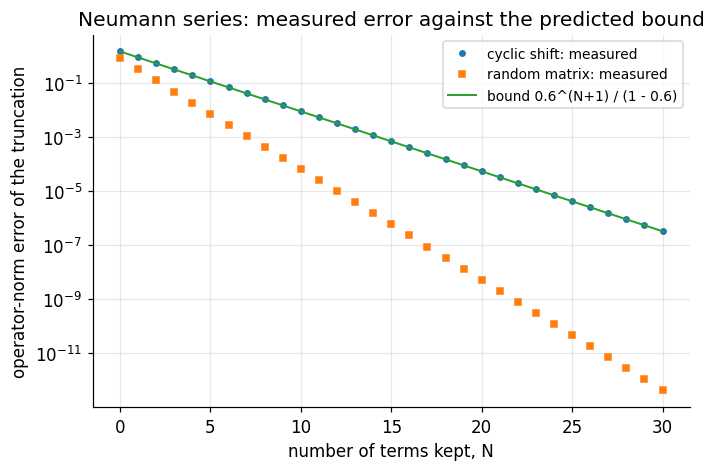

In [6]:
Pi = np.roll(np.eye(5), 1, axis=0)              # cyclic shift permutation, orthogonal
A1 = 0.6 * Pi
Mrand = rng.standard_normal((5, 5))
A2 = 0.6 * Mrand / np.linalg.norm(Mrand, 2)

Nmax = 30
curves = {}
for name, Am in [("A1 = 0.6 * cyclic shift", A1), ("A2 = 0.6 * random", A2)]:
    q = np.linalg.norm(Am, 2)
    inv = np.linalg.inv(np.eye(5) - Am)
    Ssum, Ak, errs = np.zeros((5, 5)), np.eye(5), []
    for _ in range(Nmax + 1):
        Ssum = Ssum + Ak
        Ak = Ak @ Am
        errs.append(np.linalg.norm(inv - Ssum, 2))
    errs = np.array(errs)
    curves[name] = errs
    live = errs > 1e-13
    ratios = errs[1:][live[1:]] / errs[:-1][live[1:]]
    print(f"{name}")
    print(f"  ||A||_op = {q:.6f}   ||(I - A)^-1||_op = {np.linalg.norm(inv, 2):.6f}")
    print(f"  observed contraction per term = {ratios.mean():.6f}   predicted bound = {q:.6f}")
    print(f"  error at N = 10: measured {errs[10]:.6e}   bound "
          f"{q ** 11 / (1 - q):.6e}   ratio {errs[10] / (q ** 11 / (1 - q)):.4f}")

bound = np.array([0.6 ** (N + 1) / 0.4 for N in range(Nmax + 1)])
assert np.all(curves["A1 = 0.6 * cyclic shift"] <= bound * (1 + 1e-9))
assert np.all(curves["A2 = 0.6 * random"] <= bound * (1 + 1e-9))
assert np.isclose(curves["A1 = 0.6 * cyclic shift"][10], bound[10], rtol=1e-10)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
Ns = np.arange(Nmax + 1)
ax.semilogy(Ns, curves["A1 = 0.6 * cyclic shift"], "o", ms=3.5, label="cyclic shift: measured")
ax.semilogy(Ns, curves["A2 = 0.6 * random"], "s", ms=3.5, label="random matrix: measured")
ax.semilogy(Ns, bound, lw=1.3, label="bound 0.6^(N+1) / (1 - 0.6)")
ax.set_xlabel("number of terms kept, N")
ax.set_ylabel("operator-norm error of the truncation")
ax.set_title("Neumann series: measured error against the predicted bound")
ax.legend(fontsize=9)
plt.show()

For the cyclic shift the measured contraction per term is $0.600000$, exactly the predicted
$\lVert A \rVert_{\mathrm{op}}$, and the measured error lies **on** the bound at every $N$: the
circles sit on the line. Proposition 4.11 is therefore sharp and cannot be improved as stated.

For the random matrix the bound still holds but is loose: the measured contraction is
$0.389784$ against the predicted $0.6$, and at $N = 10$ the error is $0.74$ percent of the
bound. The operator norm is an upper bound on the true per-step contraction, not the contraction
itself; the exact asymptotic factor is identified in
[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb).

### 7.3 Three hypotheses, dropped

This cell removes one hypothesis at a time and shows the breakage.

- **Additivity without homogeneity.** Complex conjugation on $\mathbb{C}$, seen as a
  one-dimensional *complex* vector space, is additive and fails $T(cz) = c\,T(z)$.
- **A mismatched middle basis.** Theorem 4.2 needs the same basis of the middle space in both
  factors; using two different ones is measured here.
- **Infinite dimension.** On the space of all polynomials, $M(p) = x\,p$ is injective and not
  surjective, which Theorem 4.5 forbids in finite dimensions.

In [7]:
print("(i) conjugation on C is additive but not homogeneous")
z1, z2, c = 1 + 2j, -3 + 0.5j, 1j
print(f"    additivity residual  |conj(z1+z2) - conj(z1) - conj(z2)| = "
      f"{abs(np.conj(z1 + z2) - np.conj(z1) - np.conj(z2)):.3e}")
print(f"    conj(c z1) = {np.conj(c * z1)}      c conj(z1) = {c * np.conj(z1)}")
print(f"    homogeneity gap      = {abs(np.conj(c * z1) - c * np.conj(z1)):.4f}   (not small)")
print("    as a map on R^2 it IS linear, with matrix diag(1, -1)")
assert abs(np.conj(z1 + z2) - np.conj(z1) - np.conj(z2)) < 1e-15
assert abs(np.conj(c * z1) - c * np.conj(z1)) > 1.0

print("\n(ii) the middle basis must be the same in both factors")
C_wrong = np.array([[1.0, 1.0], [0.0, 1.0]])          # a different basis of R^2
T_CwrongB = np.column_stack([coords(C_wrong, T_poly(B_poly[:, j])) for j in range(3)])
mixed = T_B @ T_CwrongB
true = np.column_stack([coords(C2, T_std @ T_poly(B_poly[:, j])) for j in range(3)])
print("    [S]_C [T]_{C',B} =\n", mixed)
print("    true [S o T]_{C,B} =\n", true)
print(f"    largest entrywise error = {np.abs(mixed - true).max():.4f}   (order one, not rounding)")
assert np.abs(mixed - true).max() > 0.5

print("\n(iii) infinite dimension: multiplication by x on polynomials")
for N in range(2, 7):
    Mx = np.zeros((N + 2, N + 1))
    Mx[1:, :] = np.eye(N + 1)                         # p -> x p, monomial bases
    e0 = np.zeros(N + 2)
    e0[0] = 1.0                                       # the constant polynomial 1
    _, res, rank_Mx, _ = np.linalg.lstsq(Mx, e0, rcond=None)
    print(f"    deg <= {N}: rank {rank_Mx} = domain dim {N + 1} (injective), "
          f"codomain dim {N + 2}, least-squares residual for solving Mx p = 1: "
          f"{float(res[0]) if res.size else 0.0:.4f}")
    assert rank_Mx == N + 1
    assert np.isclose(float(res[0]), 1.0)

(i) conjugation on C is additive but not homogeneous
    additivity residual  |conj(z1+z2) - conj(z1) - conj(z2)| = 0.000e+00
    conj(c z1) = (-2-1j)      c conj(z1) = (2+1j)
    homogeneity gap      = 4.4721   (not small)
    as a map on R^2 it IS linear, with matrix diag(1, -1)

(ii) the middle basis must be the same in both factors
    [S]_C [T]_{C',B} =
 [[1.5 3.  4.5]
 [1.5 1.  2.5]]
    true [S o T]_{C,B} =
 [[1.5 3.  4.5]
 [0.5 2.  2.5]]
    largest entrywise error = 1.0000   (order one, not rounding)

(iii) infinite dimension: multiplication by x on polynomials
    deg <= 2: rank 3 = domain dim 3 (injective), codomain dim 4, least-squares residual for solving Mx p = 1: 1.0000
    deg <= 3: rank 4 = domain dim 4 (injective), codomain dim 5, least-squares residual for solving Mx p = 1: 1.0000
    deg <= 4: rank 5 = domain dim 5 (injective), codomain dim 6, least-squares residual for solving Mx p = 1: 1.0000
    deg <= 5: rank 6 = domain dim 6 (injective), codomain dim 7, least-s

Conjugation adds correctly to the last bit and misses homogeneity by $2 \lvert z \rvert$ at
$c = i$: the two axioms of Definition 3.1 are genuinely independent. The same function
*is* linear over $\mathbb{R}$, which is why the underlying field belongs in the statement.

Mixing two bases of the middle space produces a matrix wrong by order one, not by rounding. The
product of two matrices is always defined; it just represents nothing.

Multiplication by $x$ has full column rank at every truncation, so it is injective, yet the
constant polynomial $1$ is never in its image — the least-squares residual is exactly $1$ for
every degree. Injective without surjective is impossible when $\dim V = \dim W \lt \infty$, and
routine when the space is infinite-dimensional.

### 7.4 Hand-rolled against the library

The next cell writes two routines from scratch and checks them against NumPy and SciPy:

- `rref`, a Gauss-Jordan elimination with partial pivoting, from which rank, a basis of the
  column space and a basis of the null space are read off;
- `matrix_of_map`, already used above, which builds $[T]_{C,B}$ column by column and is compared
  against the closed form $C^{-1} M_T B$.

In [8]:
def rref(M, tol=1e-10):
    """Reduced row echelon form with partial pivoting; returns (R, pivot columns)."""
    R = np.array(M, dtype=float)
    rows, cols = R.shape
    pivots, r = [], 0
    for c in range(cols):
        if r >= rows:
            break
        piv = r + int(np.argmax(np.abs(R[r:, c])))
        if abs(R[piv, c]) <= tol:
            continue
        R[[r, piv]] = R[[piv, r]]
        R[r] = R[r] / R[r, c]
        for i in range(rows):
            if i != r and R[i, c] != 0.0:
                R[i] = R[i] - R[i, c] * R[r]
        pivots.append(c)
        r += 1
    return R, pivots


def null_basis(M, tol=1e-10):
    """Basis of Null(M) read off the reduced row echelon form."""
    R, pivots = rref(M, tol)
    cols = M.shape[1]
    free = [c for c in range(cols) if c not in pivots]
    basis = np.zeros((cols, len(free)))
    for k, f in enumerate(free):
        basis[f, k] = 1.0
        for i, pcol in enumerate(pivots):
            basis[pcol, k] = -R[i, f]
    return basis


Btest = rng.standard_normal((7, 4)) @ rng.standard_normal((4, 9))    # 7 x 9 of rank 4
for name, M in [("A from Example 6.4", A), ("random 7 x 9 of rank 4", Btest)]:
    Rm, piv = rref(M)
    mine, lib = len(piv), np.linalg.matrix_rank(M)
    Nm, Nl = null_basis(M), null_space(M)
    fit = np.linalg.lstsq(Nm, Nl, rcond=None)[0]
    print(f"{name}")
    print(f"  rank: hand-rolled {mine}   numpy {lib}")
    print(f"  nullity: hand-rolled {Nm.shape[1]}   scipy {Nl.shape[1]}")
    print(f"  ||M @ (hand-rolled null basis)||_F = {np.linalg.norm(M @ Nm):.3e}")
    print(f"  scipy null vectors inside my span, residual = "
          f"{np.linalg.norm(Nm @ fit - Nl):.3e}")
    assert mine == lib
    assert Nm.shape[1] == Nl.shape[1]
    assert np.linalg.norm(M @ Nm) < 1e-9
    assert np.linalg.norm(Nm @ fit - Nl) < 1e-9

built = matrix_of_map(lambda v: MT @ v, Abas, Bbas)
closed = np.linalg.solve(Bbas, MT @ Abas)
print("\nmatrix_of_map against the closed form C^-1 M B")
print(f"  ||built column by column - C^-1 M B||_F = {np.linalg.norm(built - closed):.3e}"
      f"  = {np.linalg.norm(built - closed) / EPS:.2f} * eps")
assert np.allclose(built, closed)

A from Example 6.4
  rank: hand-rolled 2   numpy 2
  nullity: hand-rolled 2   scipy 2
  ||M @ (hand-rolled null basis)||_F = 4.965e-16
  scipy null vectors inside my span, residual = 5.254e-16
random 7 x 9 of rank 4
  rank: hand-rolled 4   numpy 4
  nullity: hand-rolled 5   scipy 5
  ||M @ (hand-rolled null basis)||_F = 4.638e-15
  scipy null vectors inside my span, residual = 3.294e-15

matrix_of_map against the closed form C^-1 M B
  ||built column by column - C^-1 M B||_F = 1.008e-15  = 4.54 * eps


The hand-rolled elimination reproduces NumPy's rank on both matrices, its null-space basis is
annihilated to $10^{-15}$, and every SciPy null vector is an exact linear combination of the
hand-rolled ones — the two bases span the same subspace even though they differ vector by
vector, which is all Definition 3.5 asks.

Building $[T]_{C,B}$ one column at a time agrees with $C^{-1} M_T B$ to a few machine epsilons,
which is Theorem 4.1(ii) and Theorem 4.6 arriving at the same matrix from two directions.

### 7.5 The geometry of rank and nullity

The last figure draws Theorem 4.3 for the rank-one matrix

$$
W = \begin{pmatrix} 1 & 2 \\ 2 & 4 \end{pmatrix} = v v^{\top}, \qquad v = (1, 2)^{\top} .
$$

The left panel shows the domain with the kernel line; the right panel shows the image of the unit
circle.

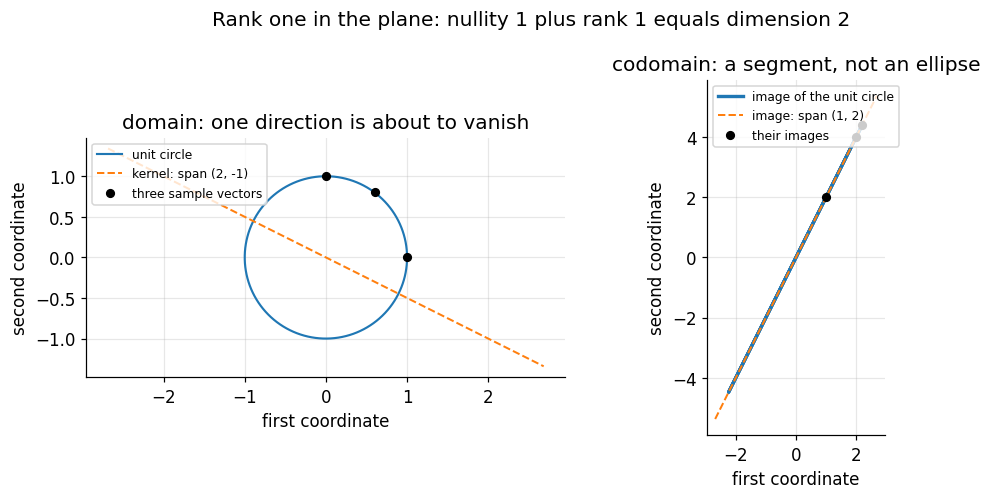

rank(W)    = 1
nullity(W) = 1
W @ kernel direction = [0. 0.]
longest image vector = 4.999977   ||W||_op = 5.000000   ||v||^2 = 5.000000


In [9]:
v = np.array([1.0, 2.0])
W = np.outer(v, v)
kernel_dir = np.array([2.0, -1.0]) / np.sqrt(5.0)
image_dir = v / np.linalg.norm(v)

t = np.linspace(0.0, 2.0 * np.pi, 400)
circle = np.vstack([np.cos(t), np.sin(t)])
image = W @ circle
samples = np.array([[1.0, 0.0], [0.0, 1.0], [0.6, 0.8]]).T

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
axes[0].plot(circle[0], circle[1], lw=1.4, label="unit circle")
axes[0].plot([-3 * kernel_dir[0], 3 * kernel_dir[0]], [-3 * kernel_dir[1], 3 * kernel_dir[1]],
             ls="--", lw=1.3, label="kernel: span (2, -1)")
axes[0].plot(samples[0], samples[1], "ko", ms=5, label="three sample vectors")
axes[0].set_title("domain: one direction is about to vanish")
axes[0].set_xlabel("first coordinate")
axes[0].set_ylabel("second coordinate")

axes[1].plot(image[0], image[1], lw=2.2, label="image of the unit circle")
axes[1].plot([-6 * image_dir[0], 6 * image_dir[0]],
             [-6 * image_dir[1], 6 * image_dir[1]], ls="--", lw=1.3,
             label="image: span (1, 2)")
img_samples = W @ samples
axes[1].plot(img_samples[0], img_samples[1], "ko", ms=5, label="their images")
axes[1].set_title("codomain: a segment, not an ellipse")
axes[1].set_xlabel("first coordinate")
axes[1].set_ylabel("second coordinate")

for ax in axes:
    ax.set_aspect("equal")
    ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Rank one in the plane: nullity 1 plus rank 1 equals dimension 2")
fig.tight_layout()
plt.show()

print("rank(W)    =", np.linalg.matrix_rank(W))
print("nullity(W) =", null_basis(W).shape[1])
print("W @ kernel direction =", W @ kernel_dir)
print(f"longest image vector = {np.max(np.linalg.norm(image, axis=0)):.6f}"
      f"   ||W||_op = {np.linalg.norm(W, 2):.6f}   ||v||^2 = {v @ v:.6f}")
assert np.linalg.matrix_rank(W) == 1
assert null_basis(W).shape[1] == 1
assert np.linalg.norm(W @ kernel_dir) < 1e-14
assert np.isclose(np.linalg.norm(W, 2), 5.0)

The circle collapses onto a segment of the line spanned by $v$: the image is one-dimensional and
the kernel line is exactly the direction that lands on the origin. One dimension in, one
dimension out, and $1 + 1 = 2$ is Theorem 4.3 for this matrix.

The longest image vector measured on the sampled circle is $4.999977$, against
$\lVert W \rVert_{\mathrm{op}} = \lVert v \rVert^2 = 5$; the shortfall is the $400$-point
discretization, not the mathematics. The operator norm of Definition 3.9 is visible as the
half-length of the segment.

## 8. Applications

Four settings in which the objects being manipulated are linear maps, and the manipulation is
one of the theorems above.

### 8.1 A neural network layer

A dense layer computes

$$
f(x) = \sigma(Wx + b), \qquad W \in \mathbb{R}^{m \times n}, \; b \in \mathbb{R}^{m},
$$

with $\sigma$ applied entrywise. The map $x \mapsto Wx$ is linear; adding $b$ makes the layer
affine, so $f(0) \neq 0$ and Definition 3.1 does not apply to it directly.

Its derivative is linear, and by the chain rule the Jacobian at $x$ is

$$
J_f(x) = \operatorname{diag}\bigl( \sigma'(Wx + b) \bigr)\, W .
$$

Stacking layers composes these Jacobians, and by Theorem 4.2 backpropagation is exactly the
matrix product taken in the reverse order. By Theorem 4.8 the rank of the composite is capped by
the narrowest layer: a bottleneck cannot be widened later.

### 8.2 Low-rank adaptation

Fine-tuning a weight matrix $W \in \mathbb{R}^{m \times n}$ by a full update costs $mn$
parameters. A **LoRA** update constrains the change to rank $r$,

$$
\Delta W = B C, \qquad B \in \mathbb{R}^{m \times r}, \; C \in \mathbb{R}^{r \times n},
$$

which is exactly the rank factorization of Theorem 4.7 used as a parameterization rather than as
a consequence.

Theorem 4.8 guarantees $\operatorname{rank}(\Delta W) \le r$, and Theorem 4.7 guarantees that
*every* matrix of rank at most $r$ is reachable in this form. The parameter count drops from
$mn$ to $r(m + n)$.

*Which* rank-$r$ matrix is the best approximation of a given target is a different question,
answered by the Eckart-Young theorem in
[Module 07](../07_canonical_forms_and_svd/first_principles.ipynb); this module supplies only the
parameterization.

### 8.3 Graphics and robotics: homogeneous coordinates

A rigid motion $x \mapsto Rx + t$ of $\mathbb{R}^3$ is affine, not linear, so it cannot be a
$3 \times 3$ matrix. Embedding the point as $(x, 1) \in \mathbb{R}^4$ makes it linear:

$$
\begin{pmatrix} R & t \\ 0^{\top} & 1 \end{pmatrix}
\begin{pmatrix} x \\ 1 \end{pmatrix}
=
\begin{pmatrix} Rx + t \\ 1 \end{pmatrix}.
$$

The gain is Theorem 4.2: a chain of joints in a robot arm, or a camera-model-view stack in a
renderer, becomes a single product of $4 \times 4$ matrices computed once.

### 8.4 Physics: the inertia tensor

For a rigid body of point masses $m_k$ at positions $r_k$ about the centre of mass, the angular
momentum is

$$
L = I \omega, \qquad
I = \sum_k m_k \bigl( \lVert r_k \rVert^2 I_3 - r_k r_k^{\top} \bigr) ,
$$

so $I$ is a linear map from angular velocity to angular momentum. Because it is a genuine map
and not a scalar, $L$ need not be parallel to $\omega$ — the source of wobble in an unbalanced
wheel.

Changing to a frame whose basis vectors are the columns of a rotation $Q$ is a change of basis
in the sense of Definition 3.7, so by Theorem 4.6

$$
I' = Q^{-1} I Q = Q^{\top} I Q ,
$$

and the trace of $I$ is frame-independent by Theorem 4.6(iii). The same similarity argument
governs the Lorentz boost: two boosts along one axis compose to a boost whose rapidity is the sum,
which is a matrix product and nothing more.

The cell below runs all four applications on small explicit objects: a finite-difference check of
the layer Jacobian, a LoRA parameter count with its rank, a composed rigid motion in homogeneous
coordinates, and an inertia tensor with its change of frame.

In [10]:
# --- 8.1 layer Jacobian --------------------------------------------------
m_out, n_in = 4, 5
Wl = rng.standard_normal((m_out, n_in))
bl = rng.standard_normal(m_out)
xl = rng.standard_normal(n_in)
sigma, dsigma = np.tanh, lambda z: 1.0 - np.tanh(z) ** 2

J_formula = np.diag(dsigma(Wl @ xl + bl)) @ Wl
h = 1e-6
J_fd = np.column_stack([(sigma(Wl @ (xl + h * np.eye(n_in)[:, j]) + bl)
                         - sigma(Wl @ (xl - h * np.eye(n_in)[:, j]) + bl)) / (2 * h)
                        for j in range(n_in)])
print("8.1 dense layer")
print(f"  ||J_formula - J_finite_difference||_F = {np.linalg.norm(J_formula - J_fd):.3e}")
assert np.linalg.norm(J_formula - J_fd) < 1e-8

# --- 8.2 LoRA ------------------------------------------------------------
m_w, n_w, r_w = 64, 64, 2
Blora = rng.standard_normal((m_w, r_w))
Clora = rng.standard_normal((r_w, n_w))
dW = Blora @ Clora
print("\n8.2 low-rank adaptation")
print(f"  rank(dW) = {np.linalg.matrix_rank(dW)}   bound from Theorem 4.8 = {r_w}")
print(f"  parameters: full {m_w * n_w}   LoRA {r_w * (m_w + n_w)}   "
      f"ratio {r_w * (m_w + n_w) / (m_w * n_w):.4f}")
assert np.linalg.matrix_rank(dW) == r_w

# --- 8.3 homogeneous coordinates -----------------------------------------
ang = np.deg2rad(37.0)
Rz = np.array([[np.cos(ang), -np.sin(ang), 0.0],
               [np.sin(ang), np.cos(ang), 0.0],
               [0.0, 0.0, 1.0]])
t1 = np.array([1.0, -2.0, 0.5])
H1 = np.eye(4)
H1[:3, :3], H1[:3, 3] = Rz, t1
H2 = np.eye(4)
H2[:3, 3] = np.array([0.0, 0.0, 2.0])
pt = rng.standard_normal(3)
composed = (H1 @ H2 @ np.append(pt, 1.0))[:3]
by_hand = Rz @ (pt + np.array([0.0, 0.0, 2.0])) + t1
print("\n8.3 homogeneous coordinates")
print("  composed 4x4 result =", composed)
print("  applied step by step =", by_hand)
print(f"  difference = {np.linalg.norm(composed - by_hand):.3e}")
assert np.allclose(composed, by_hand)

# --- 8.4 inertia tensor --------------------------------------------------
positions = np.array([[1.0, 1.0, 0.0], [-1.0, -1.0, 0.0]])
masses = np.array([1.0, 1.0])
Iten = sum(mk * ((rk @ rk) * np.eye(3) - np.outer(rk, rk)) for mk, rk in zip(masses, positions))
omega = np.array([1.0, 0.0, 0.0])
c, s = np.cos(np.pi / 4), np.sin(np.pi / 4)
Q = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
I_rot = Q.T @ Iten @ Q
print("\n8.4 inertia tensor")
print("  I =\n", Iten)
print("  L = I omega =", Iten @ omega, "  parallel to omega:",
      bool(np.allclose(np.cross(Iten @ omega, omega), 0.0)))
print("  I in the 45-degree frame =\n", I_rot)
print(f"  trace before and after   = {np.trace(Iten):.6f}  {np.trace(I_rot):.6f}")
print("  rank before and after    =", np.linalg.matrix_rank(Iten), np.linalg.matrix_rank(I_rot))
assert np.allclose(Iten, [[2.0, -2.0, 0.0], [-2.0, 2.0, 0.0], [0.0, 0.0, 4.0]])
assert np.isclose(np.trace(Iten), np.trace(I_rot))
assert np.allclose(I_rot, np.diag(np.diag(I_rot)), atol=1e-12)

8.1 dense layer
  ||J_formula - J_finite_difference||_F = 1.004e-10

8.2 low-rank adaptation
  rank(dW) = 2   bound from Theorem 4.8 = 2
  parameters: full 4096   LoRA 256   ratio 0.0625

8.3 homogeneous coordinates
  composed 4x4 result = [ 0.6709 -1.8135  2.3956]
  applied step by step = [ 0.6709 -1.8135  2.3956]
  difference = 0.000e+00

8.4 inertia tensor
  I =
 [[ 2. -2.  0.]
 [-2.  2.  0.]
 [ 0.  0.  4.]]
  L = I omega = [ 2. -2.  0.]   parallel to omega: False
  I in the 45-degree frame =
 [[ 0. -0.  0.]
 [-0.  4.  0.]
 [ 0.  0.  4.]]
  trace before and after   = 8.000000  8.000000
  rank before and after    = 2 2


The analytic Jacobian matches central differences to $10^{-10}$, so the linear map
$\operatorname{diag}(\sigma') W$ really is the derivative of the layer.

The LoRA update has rank exactly $2$, the ceiling Theorem 4.8 sets, and costs $256$ parameters
against $4096$ for a full update — a factor of $16$, from nothing but a rank factorization.

The composed rigid motion agrees with applying the two steps separately, which is Theorem 4.2 in
four dimensions.

The inertia tensor sends $\omega = (1,0,0)$ to $L = (2,-2,0)$, which is not parallel to $\omega$:
angular momentum and angular velocity point in different directions unless $\omega$ is along a
principal axis.

Rotating the frame by $45$ degrees diagonalizes $I$ and changes every entry, while the trace
stays at $8$ and the rank at $2$, as Theorem 4.6(iii) requires. The rank is $2$ and not $3$
because both masses lie on one line: spinning about that line moves nothing, so that direction
is in $\ker I$.

## 9. Key Takeaways

- **A linear map is determined by its action on a basis, and that action is a matrix.** Fixing
  ordered bases $B$ and $C$ makes $T \mapsto [T]_{C,B}$ an isomorphism
  $\mathcal{L}(V,W) \cong \mathbb{F}^{m \times n}$, so $\dim \mathcal{L}(V,W) = mn$
  (Theorem 4.1). The isomorphism is basis-dependent, never canonical.

- **Matrix multiplication is forced, not chosen.** It is the unique rule making that dictionary
  respect composition, $[S \circ T]_{C,A} = [S]_{C,B}[T]_{B,A}$, and it requires the *same*
  middle basis in both factors (Theorem 4.2).

- **Dimension is conserved**: $\dim V = \dim \ker T + \dim \operatorname{im} T$ whenever
  $\dim V \lt \infty$ (Theorem 4.3). Everything the domain loses to the kernel is missing from
  the image.

- **Every map factors through its kernel**: $V/\ker T \cong \operatorname{im} T$, with no
  finite-dimensionality needed (Theorem 4.4).

- **In equal finite dimensions, injective, surjective, bijective and invertible are the same
  condition** (Theorem 4.5). The equivalence fails without finiteness: on $\mathbb{R}[x]$,
  $p \mapsto xp$ is injective and not surjective, as Section 7.3 runs.

- **Changing basis conjugates**: $[T]_{B'} = P^{-1}[T]_B P$ (Theorem 4.6). Rank and trace survive;
  the individual entries do not, so only similarity invariants are properties of the operator.

- **If both bases may change, only the rank survives**: $A = P \Sigma_r Q$, two matrices are
  equivalent exactly when their ranks agree, row rank equals column rank, and $A = CR$ with $C$
  and $R$ of rank $r$ (Theorem 4.7).

- **Composition cannot create rank**:
  $\operatorname{rank}(A) + \operatorname{rank}(B) - n \le \operatorname{rank}(AB) \le \min \lbrace \operatorname{rank}(A), \operatorname{rank}(B) \rbrace$
  (Theorem 4.8). The upper bound is the ceiling on a low-rank adapter; the lower bound is what a
  bottleneck of width $n$ must keep.

- **The transpose is the dual map**, and the four subspaces pair off as orthogonal complements
  with dimensions $r$, $n - r$, $r$, $m - r$ (Theorem 4.9, Proposition 4.10). The step
  $(S^{\perp})^{\perp} = S$ is a dimension count, not an axiom.

- **A contraction is invertible by iteration**: $\lVert A \rVert_{\mathrm{op}} \lt 1$ gives
  $(I - A)^{-1} = \sum_k A^k$ with error at most
  $\lVert A \rVert_{\mathrm{op}}^{N+1}/(1 - \lVert A \rVert_{\mathrm{op}})$ (Proposition 4.11),
  and Section 7.2 exhibits a matrix attaining that bound at every $N$.

## 10. References

**Textbooks.**

- Axler, S. *Linear Algebra Done Right*, 3rd ed. — section 3.A (linear maps and
  $\mathcal{L}(V,W)$), section 3.B (null space, range, and the Fundamental Theorem of Linear
  Maps 3.22, which is Theorem 4.3 here), section 3.C (matrices, and $\dim \mathcal{L}(V,W) = mn$),
  section 3.D (invertibility and isomorphisms), section 3.E (products and quotients, with the
  first isomorphism theorem), section 3.F (duality, dual bases, and column rank equals row rank).
- Hoffman, K. and Kunze, R. *Linear Algebra*, 2nd ed. — sections 3.1-3.4 (linear
  transformations, the algebra of maps, isomorphism and representation by matrices), section 3.7
  (the transpose of a linear transformation).
- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed. — section 0.2 (matrix
  representations and change of basis), section 0.4 (rank, rank inequalities and Sylvester's
  inequality), section 0.7.3 (equivalence and the rank normal form).
- Meyer, C. D. *Matrix Analysis and Applied Linear Algebra* — section 4.7 (rank normal form and
  matrix equivalence), section 4.8 (the four fundamental subspaces), section 3.8 (flop counts for
  matrix products).
- Strang, G. *Linear Algebra and Learning from Data* — section I.1 ($A = CR$ and the equality of
  row and column rank), section I.9 (linear maps in learning).
- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra* — Lecture 1 (matrix-vector
  multiplication read as a linear map on the columns), Lecture 3 (operator norms and
  submultiplicativity).

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Vector spaces, bases, dimension, quotients, dual spaces and the basis extension theorem, used
  throughout Section 5: [Module 01](../01_vectors_spaces_and_subspaces/first_principles.ipynb).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).